# Reproducing Paper Figures and Tables (v9 — joint-primary)

This notebook reproduces all figures, tables, and statistics from:

**"The Convention Gap: Towards Measuring Implicit Communication in Cooperative AI Evaluation"**

v3 revision: Corrects the Full/Flawed mapping. Full (Eger 2017) and Flawed (Walton-Rivers 2017) are different agents.
Cross-dataset comparison is valid only for Outer and Intentional (both Osawa-derived).
Full appears only in HanabiData; Flawed appears only in HOAD.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import tukey_hsd
from math import sqrt, erfc

from src.analysis import (
    display_name,
    AGENT_DISPLAY_NAMES,
    add_individual_skill_columns,
    ensure_output_dir,
    plot_convention_gap_and_calibration,
    plot_convention_gap_all_settings,
    plot_three_source_calibration,
    plot_trustworthiness_inversion,
    plot_trustworthiness_inversion_paper,
    plot_predicted_vs_actual_all_settings,
    plot_game_scores_all_settings,
    plot_score_distributions,
    plot_crossplay_posterior_heatmap,
    plot_crossplay_score_heatmap,
    plot_crossplay_combined,
    logistic_analysis,
    classify_failures,
    analyze_convention_learning,
)

# Load all datasets
from src.corpus import load_hh_corpus, BOT_EXCLUSION_LIST
human_df = load_hh_corpus('../data/processed/human_play_records.csv')  # B4: bot exclusion applied
print(f'H-H corpus: {human_df["game_key"].nunique()} games, {len(human_df):,} plays, '
      f'{human_df["player"].nunique()} players (bot list: {len(BOT_EXCLUSION_LIST)} accounts excluded)')
agent_df = pd.read_csv('../data/processed/agent_play_records.csv')
human_ai_df = pd.read_csv('../data/processed/human_ai_play_records.csv')
hint_df = pd.read_csv('../data/processed/hint_records.csv')

# Ensure life_lost column exists
for df in [human_df, agent_df, human_ai_df]:
    if 'life_lost' not in df.columns:
        df['life_lost'] = (~df['was_playable']).astype(int)

# Add individual_skill and pair_type columns (per-player classification)
add_individual_skill_columns(human_df)

# Human plays only from human-AI data
hai_human = human_ai_df[human_ai_df['subject_type'] == 'human'].copy()
if 'life_lost' not in hai_human.columns:
    hai_human['life_lost'] = (~hai_human['was_playable']).astype(int)

print(f'Human-Human:  {len(human_df):,} play records')
print(f'AI-AI:        {len(agent_df):,} play records')
print(f'Human-vs-AI:  {len(human_ai_df):,} play records ({len(hai_human):,} human plays)')
print(f'Hint records: {len(hint_df):,}')
print(f'\nPair type distribution:')
print(human_df['pair_type'].value_counts().to_string())

H-H corpus: 425 games, 9,017 plays, 155 players (bot list: 42 accounts excluded)
Human-Human:  9,017 play records
AI-AI:        62,890 play records
Human-vs-AI:  29,049 play records (15,472 human plays)
Hint records: 195,634

Pair type distribution:
pair_type
intermediate-intermediate    3708
expert-expert                3268
beginner-beginner            1499
intermediate-beginner         279
expert-intermediate           194
expert-beginner                69


In [2]:
# v9 JOINT-PRIMARY SWAP (inserted after data loading; v9 preprint wave 2026-08-17)
# Attach the exact full-hand joint posterior to every corpus and make it THE
# posterior (posterior_p_life_loss). The v8 marginal is kept as
# 'posterior_marg_v8'. Aborts if any play fails to join or the recomputed
# marginal disagrees with the shipped per-play posterior.
from src.joint_replay import load_joint_posteriors as _ljp
_joint = _ljp()

def _swap_to_joint(df, source):
    j = _joint[_joint['data_source'] == source][
        ['game_key', 'turn', 'posterior_marginal', 'posterior_joint']]
    out = df.copy()
    out['game_key'] = out['game_key'].astype(str)
    out = out.merge(j, on=['game_key', 'turn'], how='left', validate='one_to_one')
    assert out['posterior_joint'].notna().all(), f'{source}: unmatched joins'
    _dmax = (out['posterior_marginal'] - out['posterior_p_life_loss']).abs().max()
    assert _dmax < 1e-9, f'{source}: marginal mismatch {_dmax}'
    out['posterior_marg_v8'] = out['posterior_p_life_loss']
    out['posterior_p_life_loss'] = out['posterior_joint']
    return out.drop(columns=['posterior_marginal', 'posterior_joint'])

human_df = _swap_to_joint(human_df, 'hanab_live')
agent_df = _swap_to_joint(agent_df, 'hoad')
human_ai_df = _swap_to_joint(human_ai_df, 'hanabi_data')
hai_human = human_ai_df[human_ai_df['subject_type'] == 'human'].copy()
for _n, _d in [('H-H', human_df), ('H-AI human', hai_human), ('AI-AI', agent_df)]:
    _gj = (_d['posterior_p_life_loss'].mean() - _d['life_lost'].mean()) * 100
    _gm = (_d['posterior_marg_v8'].mean() - _d['life_lost'].mean()) * 100
    print(f'{_n}: {len(_d):,} plays; joint gap {_gj:+.2f} pp (marginal was {_gm:+.2f} pp)')
print('v9 swap complete: posterior_p_life_loss is the JOINT posterior for all downstream cells')


H-H: 9,017 plays; joint gap +26.16 pp (marginal was +28.20 pp)
H-AI human: 15,472 plays; joint gap +16.38 pp (marginal was +16.87 pp)
AI-AI: 62,890 plays; joint gap -0.74 pp (marginal was -0.54 pp)
v9 swap complete: posterior_p_life_loss is the JOINT posterior for all downstream cells


---
## Headline Statistics

Key statistics cited throughout the manuscript.

In [3]:
# Convention gap headline numbers
def convention_gap_table(df, label):
    n = len(df)
    mean_post = df['posterior_p_life_loss'].mean()
    actual = df['life_lost'].mean()
    gap = mean_post - actual
    rng = np.random.default_rng(42)
    boot_gaps = []
    for _ in range(2000):
        idx = rng.choice(n, n, replace=True)
        bg = df['posterior_p_life_loss'].iloc[idx].mean() - df['life_lost'].iloc[idx].mean()
        boot_gaps.append(bg)
    ci_lo, ci_hi = np.percentile(boot_gaps, [2.5, 97.5])
    return {'Setting': label, 'N': n, 'Mean P(loss)': f'{mean_post:.1%}',
            'Actual Loss': f'{actual:.1%}', 'Conv. Gap': f'{gap:+.1%}',
            '95% CI': f'[{ci_lo:.1%}, {ci_hi:.1%}]'}

rows = [
    convention_gap_table(human_df, 'Human-Human'),
    convention_gap_table(hai_human, 'Human-vs-AI'),
    convention_gap_table(agent_df, 'AI-AI'),
]
table_headline = pd.DataFrame(rows)
print('Convention Gap Across Settings')
print(table_headline.to_string(index=False))

Convention Gap Across Settings
    Setting     N Mean P(loss) Actual Loss Conv. Gap         95% CI
Human-Human  9017        31.4%        5.3%    +26.2% [25.5%, 26.8%]
Human-vs-AI 15472        39.1%       22.7%    +16.4% [15.8%, 16.9%]
      AI-AI 62890         8.7%        9.4%     -0.7% [-0.9%, -0.6%]


---
## Figure 1(a,b,c): Game Score, Convention Gap, and Calibration

Three-panel figure: (a) violin plot of game scores by setting, (b) 3-bar convention gap by setting, (c) calibration curve.
Saved as `figure1_convention_gap_and_calibration.png`.

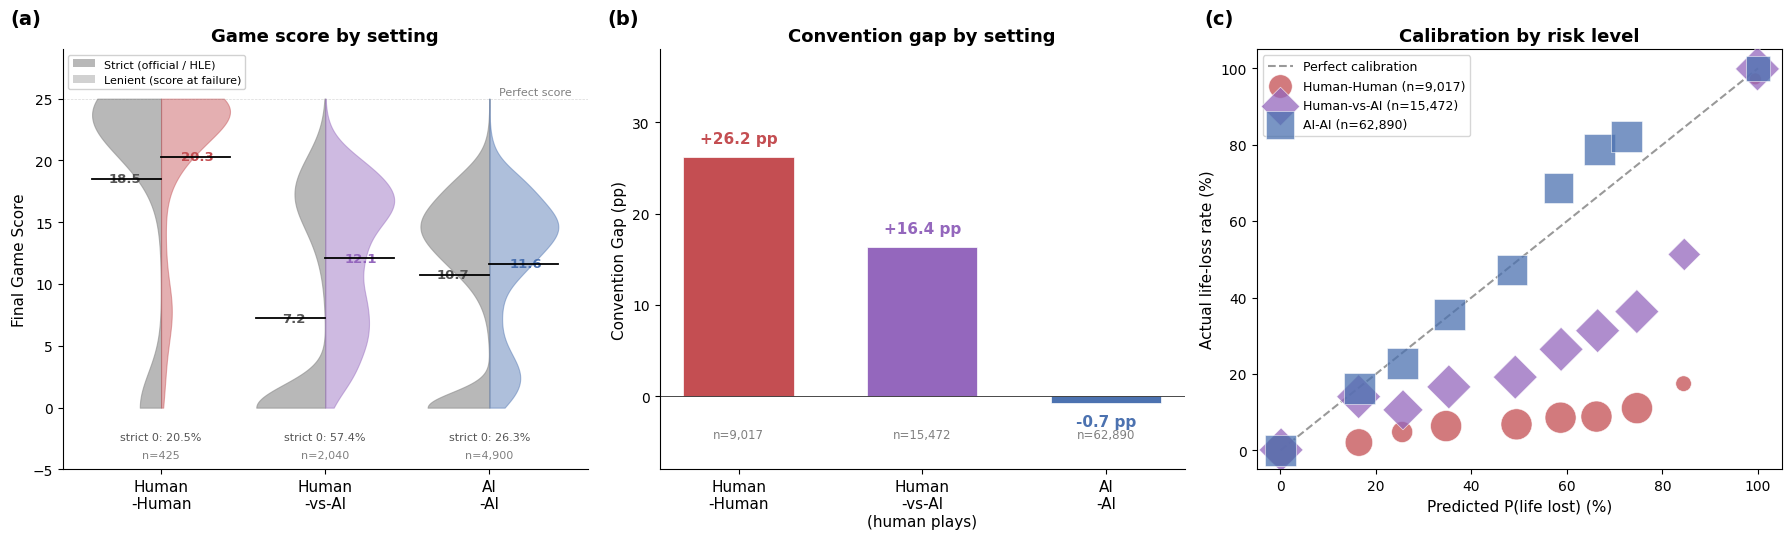

In [4]:
fig1 = plot_convention_gap_and_calibration(human_df, agent_df, human_ai_df)
plt.show()

### Figure 1(a): strict vs lenient game score (split-violin annotations)

Panel (a) now shows a split violin per setting: left half = **strict** scoring (three life losses → 0, HLE / official rule), right half = **lenient** scoring (tableau total at the moment of failure, the older human-subject convention). The cell below prints the annotated means, strict zero-fractions, and the Welch tests, including the H-AI vs AI-AI sign flip (strict −3.5 → lenient +0.4 points).

In [5]:
from src.analysis import lenient_score_stats

ls = lenient_score_stats(human_df, agent_df, human_ai_df)
print('Strict (official, 3-strike=0) vs Lenient (score at failure) end-of-game score:')
hdr = f"{'setting':<12}{'strict mean (SD)':>20}{'lenient mean (SD)':>20}{'strict-0%':>11}"
print(hdr)
for name in ['Human-Human', 'Human-AI', 'AI-AI']:
    r = ls[name]
    s = f"{r['strict_mean']:.2f} ({r['strict_sd']:.1f})"
    l = f"{r['lenient_mean']:.2f} ({r['lenient_sd']:.1f})"
    print(f"{name:<12}{s:>20}{l:>20}{r['zero_frac_pct']:>10.1f}%")
print()
t = ls['tests']
print(f"Welch H-AI vs AI-AI: lenient t={t['lenient_HAI_vs_AA']['t']} "
      f"(p={t['lenient_HAI_vs_AA']['p']:.4f}, d={t['lenient_HAI_vs_AA']['d']})  "
      f"<- SIGN REVERSED vs strict t={t['strict_HAI_vs_AA']['t']}")
print(f"Welch H-H vs H-AI:  lenient t={t['lenient_HH_vs_HAI']['t']} "
      f"(p={t['lenient_HH_vs_HAI']['p']:.2e}, d={t['lenient_HH_vs_HAI']['d']})")

Strict (official, 3-strike=0) vs Lenient (score at failure) end-of-game score:
setting         strict mean (SD)   lenient mean (SD)  strict-0%
Human-Human          18.52 (9.6)         20.31 (6.5)      20.5%
Human-AI              7.22 (8.6)         12.07 (5.7)      57.4%
AI-AI                10.73 (6.9)         11.63 (5.6)      26.3%

Welch H-AI vs AI-AI: lenient t=2.94 (p=0.0033, d=0.078)  <- SIGN REVERSED vs strict t=-16.45
Welch H-H vs H-AI:  lenient t=24.38 (p=1.84e-90, d=1.352)


---
## Table 1: Convention Gap by Hint Count

In [6]:
def gap_by_hints(df, hint_val):
    if hint_val == '2+':
        sub = df[df['hints_on_card'] >= 2]
    else:
        sub = df[df['hints_on_card'] == hint_val]
    if len(sub) == 0:
        return 0.0
    return sub['posterior_p_life_loss'].mean() - sub['life_lost'].mean()

hint_rows = []
for h in [0, 1, '2+']:
    hint_rows.append({
        'Hints on card': h,
        'Human-Human': f'{gap_by_hints(human_df, h):+.0%}',
        'Human-AI': f'{gap_by_hints(hai_human, h):+.0%}',
        'AI-AI': f'{gap_by_hints(agent_df, h):+.0%}',
    })
table1 = pd.DataFrame(hint_rows)
print('Table 1: Convention Gap by Hint Count')
print(table1.to_string(index=False))

# Zero-hint z-test: H-H vs H-AI
hh_zero = human_df[human_df['hints_on_card'] == 0]
hai_zero = hai_human[hai_human['hints_on_card'] == 0]
p1 = hh_zero['was_playable'].mean()
p2 = hai_zero['was_playable'].mean()
n1, n2 = len(hh_zero), len(hai_zero)
se = sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
z = (p1 - p2) / se
p_val = erfc(abs(z) / sqrt(2))
print(f'\nZero-hint success: H-H {p1:.1%} vs H-AI {p2:.1%}, z={z:.2f}, p={p_val:.2e}')

Table 1: Convention Gap by Hint Count
Hints on card Human-Human Human-AI AI-AI
            0        +46%     -12%  -13%
            1        +36%     +25%   +1%
           2+         +2%      +1%   -0%

Zero-hint success: H-H 77.7% vs H-AI 15.7%, z=26.98, p=2.45e-160


---
## Figure 2: Convention Gap by Player Type (Human vs AI plays)

Full            Human: +24.1% (n=4,769, CI [23.2%, 25.1%])
                AI:    +16.9% (n=5,965, CI [16.0%, 17.8%])
Intentional     Human: +20.2% (n=5,122, CI [19.3%, 21.2%])
                AI:    +0.0% (n=4,979, CI [-0.0%, 0.0%])
Outer           Human: +6.2% (n=5,581, CI [5.2%, 7.2%])
                AI:    -0.0% (n=2,633, CI [-0.0%, 0.0%])
Saved to output/figures/ and Manuscript/figures/


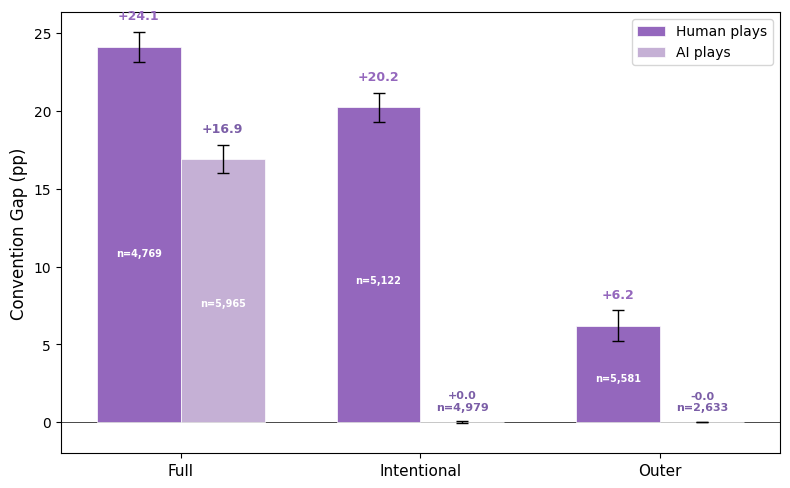

In [7]:
from src.analysis import display_name

def _gap_with_ci(sdf, n_boot=10000, seed=42):
    """Compute convention gap and 95% bootstrap percentile CI."""
    sdf = sdf.copy()
    if "life_lost" not in sdf.columns:
        sdf["life_lost"] = (~sdf["was_playable"]).astype(int)
    posterior = sdf["posterior_p_life_loss"].values
    life_lost = sdf["life_lost"].values
    gap = posterior.mean() - life_lost.mean()
    n = len(sdf)
    rng = np.random.default_rng(seed)
    boot_gaps = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_gaps[b] = posterior[idx].mean() - life_lost[idx].mean()
    ci_lo, ci_hi = np.percentile(boot_gaps, [2.5, 97.5])
    return gap, n, ci_lo, ci_hi

ai_order = ["full", "intentional", "outer"]

# Compute gaps
human_gaps = []
ai_gaps = []
for ai in ai_order:
    sub_h = human_ai_df[(human_ai_df["subject_type"] == "human") & (human_ai_df["partner_type"] == ai)]
    human_gaps.append(_gap_with_ci(sub_h))
    sub_a = human_ai_df[human_ai_df["subject_type"] == ai]
    ai_gaps.append(_gap_with_ci(sub_a))

# Print for verification
for i, ai in enumerate(ai_order):
    g_h, n_h, lo_h, hi_h = human_gaps[i]
    g_a, n_a, lo_a, hi_a = ai_gaps[i]
    print(f"{display_name(ai):15s} Human: {g_h:+.1%} (n={n_h:,}, CI [{lo_h:.1%}, {hi_h:.1%}])")
    print(f"{'':15s} AI:    {g_a:+.1%} (n={n_a:,}, CI [{lo_a:.1%}, {hi_a:.1%}])")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

bar_width = 0.35
group_positions = np.arange(len(ai_order))
x_human = group_positions - bar_width / 2
x_ai = group_positions + bar_width / 2

color_human = "#9467bd"
color_ai = "#c5b0d5"
color_ai_text = "#7b5ea7"

# Human bars
h_vals = [g[0] * 100 for g in human_gaps]
h_err_lo = [((g[0] - g[2]) * 100) for g in human_gaps]
h_err_hi = [((g[3] - g[0]) * 100) for g in human_gaps]
bars_h = ax.bar(x_human, h_vals, bar_width, color=color_human, edgecolor="white",
                linewidth=0.5, label="Human plays", zorder=3,
                yerr=[h_err_lo, h_err_hi], capsize=4,
                error_kw=dict(ecolor="black", lw=1, capthick=1, zorder=4))

# AI bars
a_vals = [g[0] * 100 for g in ai_gaps]
a_err_lo = [((g[0] - g[2]) * 100) for g in ai_gaps]
a_err_hi = [((g[3] - g[0]) * 100) for g in ai_gaps]
bars_a = ax.bar(x_ai, a_vals, bar_width, color=color_ai, edgecolor="white",
                linewidth=0.5, label="AI plays", zorder=3,
                yerr=[a_err_lo, a_err_hi], capsize=4,
                error_kw=dict(ecolor="black", lw=1, capthick=1, zorder=4))

# Value + n labels
for i in range(len(ai_order)):
    # Human bar — value above error bar
    y_top_h = h_vals[i] + h_err_hi[i]
    ax.text(x_human[i], y_top_h + 0.6, f"{h_vals[i]:+.1f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color=color_human)
    # Human bar — n inside bar
    ax.text(x_human[i], h_vals[i] * 0.45, f"n={human_gaps[i][1]:,}",
            ha="center", va="center", fontsize=7, color="white", fontweight="bold")

    # AI bar
    if abs(a_vals[i]) < 1.0:
        # Near-zero bars: value + n stacked above
        ci_top = max(a_vals[i] + a_err_hi[i], abs(a_vals[i]) + a_err_lo[i])
        ax.text(x_ai[i], ci_top + 0.6, f"{a_vals[i]:+.1f}\nn={ai_gaps[i][1]:,}",
                ha="center", va="bottom", fontsize=8, fontweight="bold", color=color_ai_text,
                linespacing=1.2)
    else:
        y_top_a = a_vals[i] + a_err_hi[i]
        ax.text(x_ai[i], y_top_a + 0.6, f"{a_vals[i]:+.1f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold", color=color_ai_text)
        ax.text(x_ai[i], a_vals[i] * 0.45, f"n={ai_gaps[i][1]:,}",
                ha="center", va="center", fontsize=7, color="white", fontweight="bold")

ax.set_xticks(group_positions)
ax.set_xticklabels([display_name(ai) for ai in ai_order], fontsize=11)
ax.set_ylabel("Convention Gap (pp)", fontsize=12)
ax.axhline(0, color="black", linewidth=0.5, zorder=1)
ax.legend(fontsize=10, loc="upper right")
ax.set_xlim(-0.5, len(ai_order) - 0.5)
ax.set_ylim(-2, None)

fig.tight_layout()
fig.savefig("../output/figures/convention_gap_human_vs_ai_plays.png", dpi=150)

import shutil
from pathlib import Path
_tgt = Path("../../Manuscript/figures/convention_gap_human_vs_ai_plays.png")
if _tgt.parent.exists():
    shutil.copy2("../output/figures/convention_gap_human_vs_ai_plays.png", str(_tgt))
    print("Saved to output/figures/ and Manuscript/figures/")
else:
    print("Saved to output/figures/ (Manuscript/figures/ not present; skipping copy)")
plt.show()

---
## Figure 3: Trustworthiness Inversion

Slopegraph showing Partner Loss ranking inversion between AI-AI and Human-AI settings.
Saved as `crossphase_trustworthiness_inversion.png`.

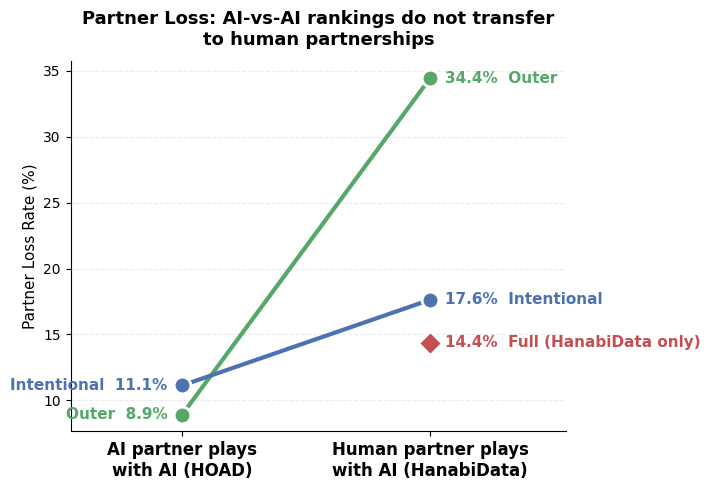

In [8]:
# Figure 3 (v3): Trustworthiness Inversion
# Option A: Outer and Intentional with cross-dataset lines;
# Full as HanabiData-only point (diamond marker)
fig2 = plot_trustworthiness_inversion(human_ai_df, agent_df)
plt.show()


---
## Appendix D — Logistic Regression (Table A2, Figure A1)

Logistic regression predicting life loss from the posterior and contextual features.
ROC curves saved as `phase8_logistic_roc.png`.


=== 8.1 Logistic Regression Results ===

Dataset         Model                 N      AUC  Pseudo-R²  β(posterior)
----------------------------------------------------------------------
human           M1_posterior      9,017   0.8146     0.1935        5.3060
human           M2_context        9,017   0.8330     0.2189        5.0251
human           M3_full           9,017   0.8518     0.2489        4.9221
agent           M1_posterior     62,890   0.9802     0.6334        9.6248
agent           M2_context       62,890   0.9802     0.6399        8.3607
agent           M3_full          62,890   0.9802     0.6399        8.3607
human_ai        M1_posterior     15,472   0.8705     0.3484        6.0112
human_ai        M2_context       15,472   0.8856     0.3707        5.8013
human_ai        M3_full          15,472   0.9115     0.4277        6.0683


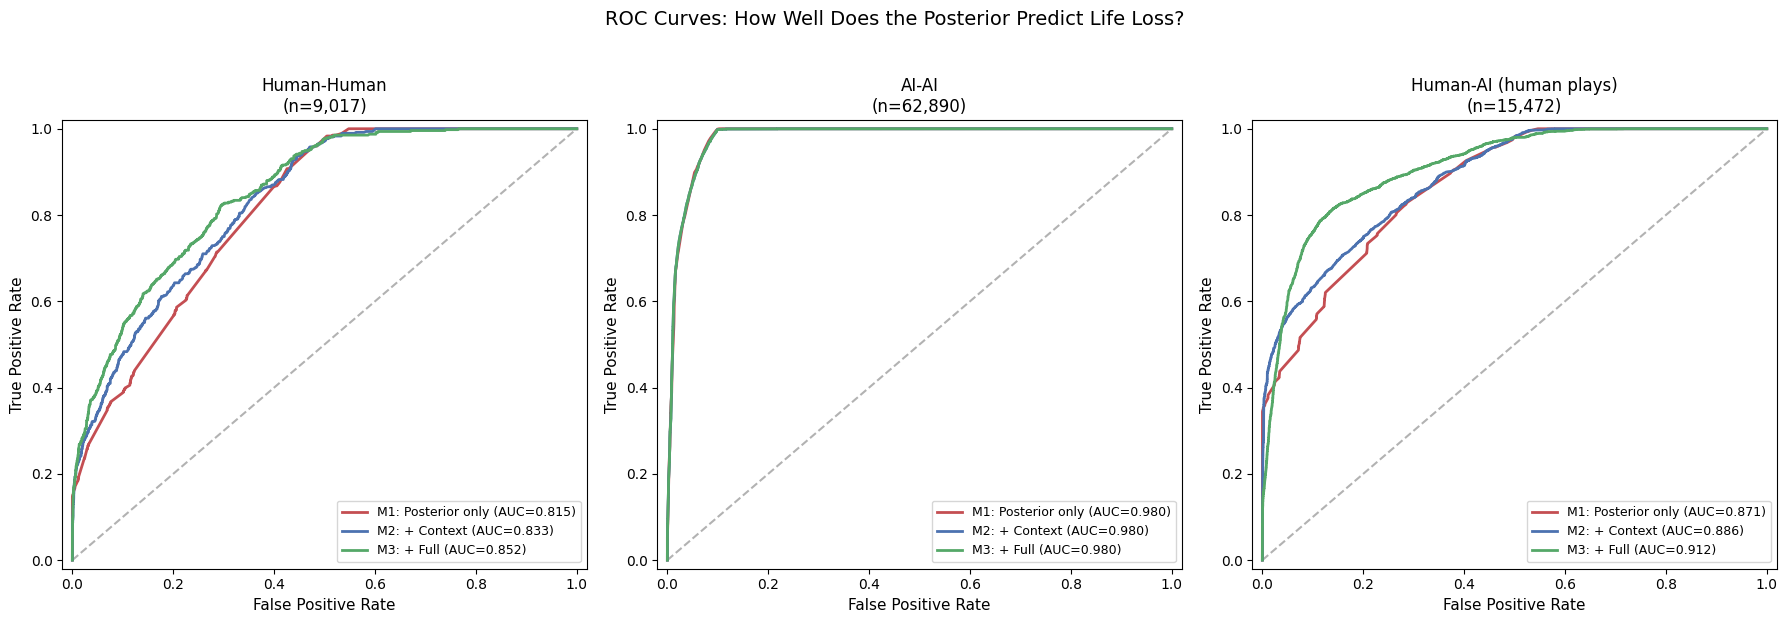

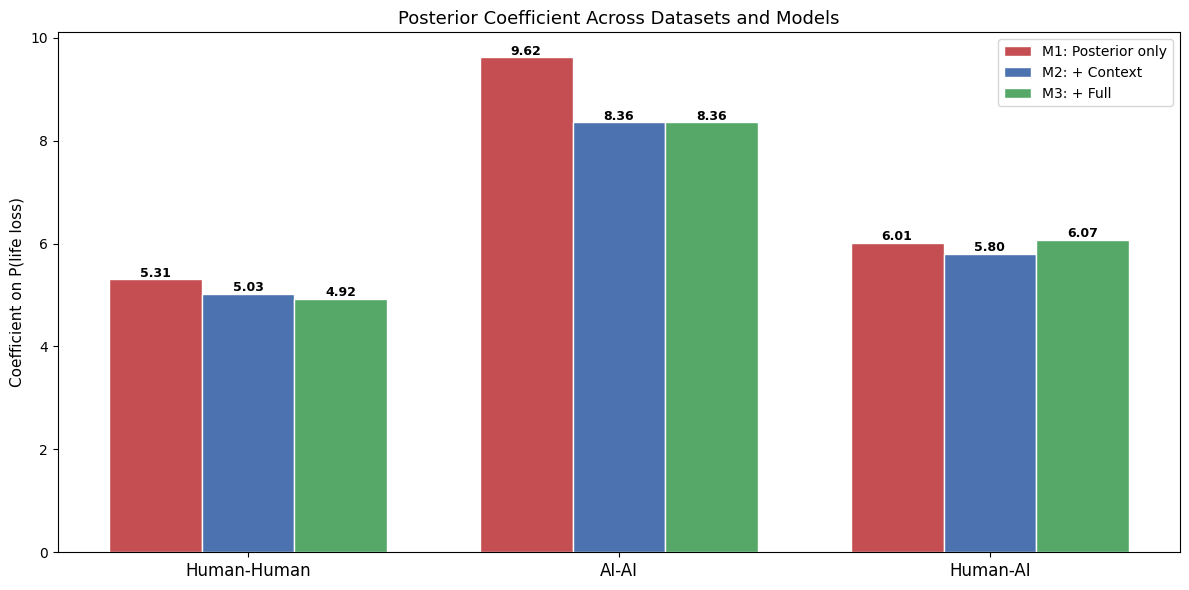

In [9]:
logistic_results = logistic_analysis(human_df, agent_df, human_ai_df)
plt.show()

---
## Appendix F — Skill Modulation (Table A3)

Convention gap by pair type (individual player skill). ANOVA and Tukey HSD.

In [3]:
pair_order = [
    ('expert-expert', 'Expert-Expert'),
    ('expert-intermediate', 'Expert-Interm.'),
    ('intermediate-intermediate', 'Interm.-Interm.'),
    ('intermediate-beginner', 'Interm.-Beginner'),
    ('beginner-beginner', 'Beginner-Beginner'),
]

pair_rows = []
for pair_key, pair_label in pair_order:
    sub = human_df[human_df['pair_type'] == pair_key]
    if len(sub) == 0:
        continue
    n = len(sub)
    mean_post = sub['posterior_p_life_loss'].mean()
    actual = sub['life_lost'].mean()
    gap = mean_post - actual
    pair_rows.append({
        'Pair Type': pair_label,
        'N': f'{n:,}',
        'Mean P(loss)': f'{mean_post:.1%}',
        'Actual Loss': f'{actual:.1%}',
        'Conv. Gap': f'{gap:+.1%}',
    })
table_skill = pd.DataFrame(pair_rows)
print('Table A2: Convention Gap by Pair Type (Individual Player Skill)')
print(table_skill.to_string(index=False))

# ANOVA
groups = []
group_labels = []
for pair_key, pair_label in pair_order:
    sub = human_df[human_df['pair_type'] == pair_key]
    if len(sub) > 0:
        groups.append(sub['posterior_p_life_loss'].values - sub['life_lost'].values)
        group_labels.append(pair_label)

f_stat, p_val = stats.f_oneway(*groups)
n_groups = len(groups)
n_resid = sum(len(g) for g in groups) - n_groups  # residual df over the plays entering the ANOVA
print(f'\nANOVA: F({n_groups - 1}, {n_resid}) = {f_stat:.2f}, p = {p_val:.2e} (N = {sum(len(g) for g in groups):,} plays in {n_groups} pair types)')

# Tukey HSD
result = tukey_hsd(*groups)
print(f'\nTukey HSD pairwise comparisons (p-values):')
header = ' ' * 20 + ''.join(f'{lbl:>20}' for lbl in group_labels)
print(header)
for i, lbl_i in enumerate(group_labels):
    row_str = f'{lbl_i:>20}'
    for j in range(len(group_labels)):
        if i == j:
            row_str += ' ' * 19 + '\u2014'
        else:
            pv = result.pvalue[i][j]
            sig = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else 'ns'
            cell = f'{pv:.4f} {sig:>3s}'
            row_str += cell.rjust(20)
    print(row_str)

Table A2: Convention Gap by Pair Type (Individual Player Skill)
        Pair Type     N Mean P(loss) Actual Loss Conv. Gap
    Expert-Expert 3,268        31.6%        2.5%    +29.1%
   Expert-Interm.   194        28.8%        3.6%    +25.2%
  Interm.-Interm. 3,708        30.2%        4.8%    +25.4%
 Interm.-Beginner   279        36.1%        9.0%    +27.2%
Beginner-Beginner 1,499        33.1%       12.0%    +21.1%

ANOVA: F(4, 8943) = 16.41, p = 2.11e-13 (N = 8,948 plays in 5 pair types)

Tukey HSD pairwise comparisons (p-values):
                           Expert-Expert      Expert-Interm.     Interm.-Interm.    Interm.-Beginner   Beginner-Beginner
       Expert-Expert                   —          0.4891  ns          0.0000 ***          0.8738  ns          0.0000 ***
      Expert-Interm.          0.4891  ns                   —          1.0000  ns          0.9693  ns          0.4591  ns
     Interm.-Interm.          0.0000 ***          1.0000  ns                   —          0.8959  ns

---
## Appendix G — Hint Quality Metrics (Figure A2)

Three panels: (a) disambiguation power, (b) playability rate, (c) target's next action.
Saved as `phase8_hint_quality.png`.

Play-Signal Accuracy (hint → linked next-turn play → observed failure):
Hinter            Hints  →play %  linked n  observed failure %
----------------------------------------------------------------
Full              6,412    56.6%     3,631                7.6%
Intentional       6,551    56.1%     3,676                8.3%
Outer             7,125    59.7%     4,253               30.8%



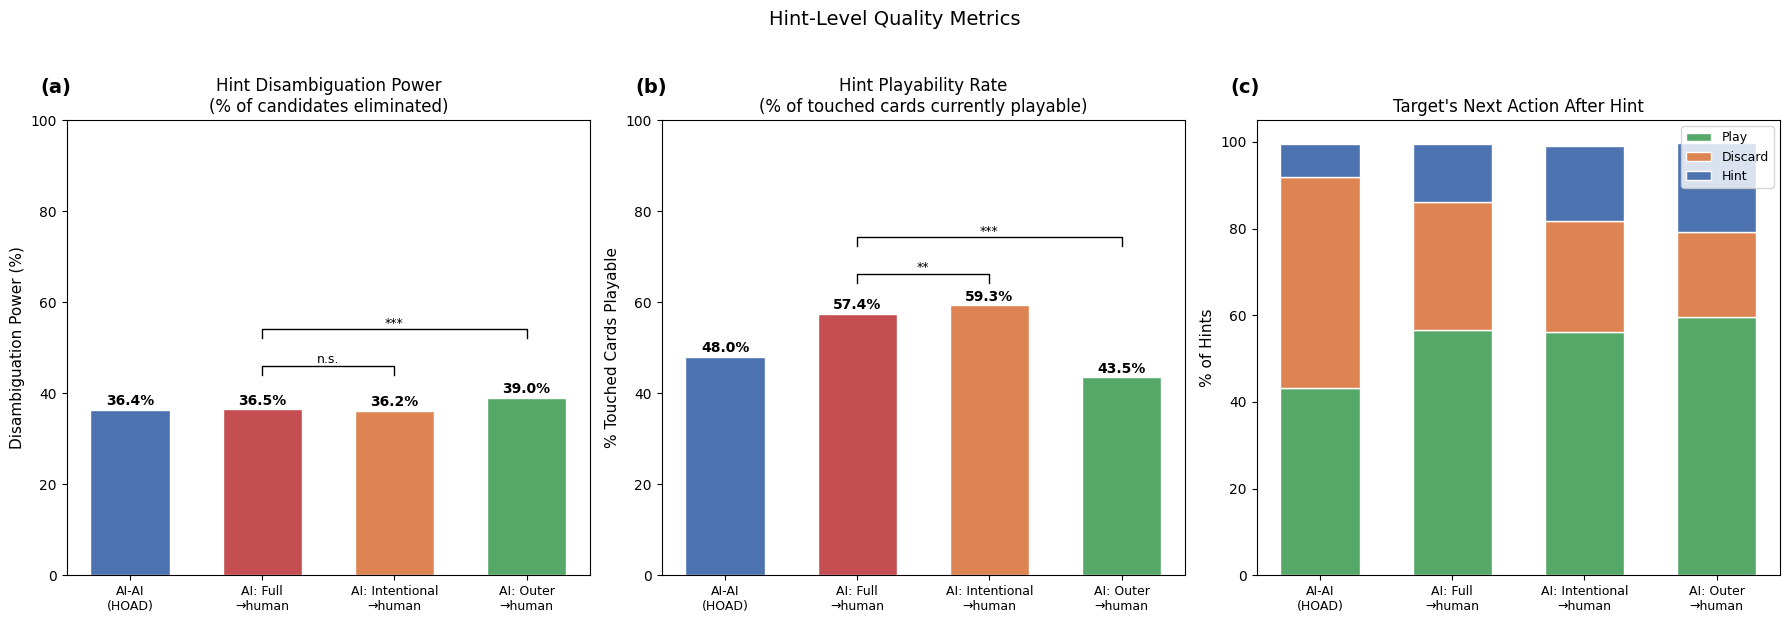

In [4]:
from pathlib import Path
from src.analysis import link_hint_to_next_play

out = ensure_output_dir()

# Filter hint records by source
ai_hints_hai = hint_df[(hint_df['data_source'] == 'hanabi_data') & (hint_df['hinter_type'] != 'human')]

# Play-Signal Accuracy: observed outcome of the play at (game_id, turn + 1),
# linked via link_hint_to_next_play (replaces the playable_cards_touched proxy)
human_plays_hai = human_ai_df[human_ai_df['subject_type'] == 'human']
print('Play-Signal Accuracy (hint \u2192 linked next-turn play \u2192 observed failure):')
print(f"{'Hinter':<15} {'Hints':>7} {'\u2192play %':>8} {'linked n':>9} {'observed failure %':>19}")
print('-' * 64)
for ai_type in ['full', 'intentional', 'outer']:
    sdf = ai_hints_hai[ai_hints_hai['hinter_type'] == ai_type]
    linked = link_hint_to_next_play(sdf, human_plays_hai)
    n_linked = int(linked.notna().sum())
    play_frac = (sdf['next_action_by_target'] == 'play').mean() * 100
    print(f"{display_name(ai_type):<15} {len(sdf):>7,} {play_frac:>7.1f}% {n_linked:>9,} {linked.mean()*100:>18.1f}%")
print()

sources = [
    ('AI-AI\n(HOAD)', hint_df[hint_df['data_source'] == 'hoad'], '#4c72b0'),
    (f'AI: {display_name("full")}\n\u2192human', ai_hints_hai[ai_hints_hai['hinter_type'] == 'full'], '#c44e52'),
    (f'AI: {display_name("intentional")}\n\u2192human', ai_hints_hai[ai_hints_hai['hinter_type'] == 'intentional'], '#dd8452'),
    (f'AI: {display_name("outer")}\n\u2192human', ai_hints_hai[ai_hints_hai['hinter_type'] == 'outer'], '#55a868'),
]
sources = [(lbl, sdf, clr) for lbl, sdf, clr in sources if len(sdf) > 0]

labels_src = [s[0] for s in sources]
colors_src = [s[2] for s in sources]

fig3, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel (a): Disambiguation power
ax = axes[0]
vals = [s[1]['disambiguation_power'].mean() * 100 for s in sources]
bars = ax.bar(range(len(labels_src)), vals, color=colors_src, edgecolor='white', width=0.6)
ax.set_xticks(range(len(labels_src)))
ax.set_xticklabels(labels_src, fontsize=9)
ax.set_ylabel('Disambiguation Power (%)', fontsize=11)
ax.set_title('Hint Disambiguation Power\n(% of candidates eliminated)', fontsize=12)
ax.set_ylim(0, 100)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.text(-0.05, 1.05, '(a)', transform=ax.transAxes, fontsize=14, fontweight='bold', va='bottom')

# Significance brackets for panel (a): Full vs Intentional n.s., both vs Outer ***
def add_bracket(ax, x1, x2, y, text, h=2):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color='black', linewidth=1)
    ax.text((x1+x2)/2, y+h+0.5, text, ha='center', fontsize=9)

# Brackets only between the 3 H-AI agents (indices 1, 2, 3)
y_max_a = max(vals[1:]) + 5
add_bracket(ax, 1, 2, y_max_a, 'n.s.')
add_bracket(ax, 1, 3, y_max_a + 8, '***')

# Panel (b): Playability rate
ax = axes[1]
vals2 = []
for _, sdf, _ in sources:
    total = sdf['cards_touched'].sum()
    vals2.append(sdf['playable_cards_touched'].sum() / max(total, 1) * 100)
bars = ax.bar(range(len(labels_src)), vals2, color=colors_src, edgecolor='white', width=0.6)
ax.set_xticks(range(len(labels_src)))
ax.set_xticklabels(labels_src, fontsize=9)
ax.set_ylabel('% Touched Cards Playable', fontsize=11)
ax.set_title('Hint Playability Rate\n(% of touched cards currently playable)', fontsize=12)
ax.set_ylim(0, 100)
for bar, val in zip(bars, vals2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.text(-0.05, 1.05, '(b)', transform=ax.transAxes, fontsize=14, fontweight='bold', va='bottom')

# Significance brackets for panel (b): Full vs Intentional **, both vs Outer ***
y_max_b = max(vals2[1:]) + 5
add_bracket(ax, 1, 2, y_max_b, '**')
add_bracket(ax, 1, 3, y_max_b + 8, '***')

# Panel (c): Next action after hint
ax = axes[2]
action_types = ['play', 'discard', 'hint']
x_pos = np.arange(len(labels_src))
bottom = np.zeros(len(labels_src))
action_colors = {'play': '#55a868', 'discard': '#dd8452', 'hint': '#4c72b0'}
for act in action_types:
    fracs = [(sdf['next_action_by_target'] == act).mean() * 100 for _, sdf, _ in sources]
    ax.bar(x_pos, fracs, bottom=bottom, width=0.6, label=act.capitalize(),
           color=action_colors[act], edgecolor='white')
    bottom += fracs
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_src, fontsize=9)
ax.set_ylabel('% of Hints', fontsize=11)
ax.set_title("Target's Next Action After Hint", fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 105)
ax.text(-0.05, 1.05, '(c)', transform=ax.transAxes, fontsize=14, fontweight='bold', va='bottom')

fig3.suptitle('Hint-Level Quality Metrics', fontsize=14, y=1.03)
fig3.tight_layout()
fig3.savefig(out / 'phase8_hint_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Hint Quality Statistics

Playability chi-squared, disambiguation ANOVA, Full vs Intentional comparisons.

In [12]:
# Playability chi-squared
from scipy.stats import chi2_contingency

playable_counts = []
total_counts = []
for ai in ['full', 'intentional', 'outer']:
    sub = ai_hints_hai[ai_hints_hai['hinter_type'] == ai]
    playable_counts.append(sub['playable_cards_touched'].sum())
    total_counts.append(sub['cards_touched'].sum())
not_playable = [t - p for t, p in zip(total_counts, playable_counts)]
contingency = np.array([playable_counts, not_playable])
chi2, p_chi, dof, _ = chi2_contingency(contingency)
print(f'Playability chi-squared: chi2({dof}) = {chi2:.2f}, p = {p_chi:.2e}')

# Disambiguation ANOVA
disam_groups = []
for ai in ['full', 'intentional', 'outer']:
    sub = ai_hints_hai[ai_hints_hai['hinter_type'] == ai]
    disam_groups.append(sub['disambiguation_power'].dropna().values)
f_disam, p_disam = stats.f_oneway(*disam_groups)
n_total = sum(len(g) for g in disam_groups)
print(f'Disambiguation ANOVA: F(2, {n_total-3}) = {f_disam:.2f}, p = {p_disam:.2e}')

# Full vs Intentional Partner Loss z-test
full_plays = hai_human[hai_human['partner_type'] == 'full']
intent_plays = hai_human[hai_human['partner_type'] == 'intentional']
n1, x1 = len(full_plays), full_plays['life_lost'].sum()
n2, x2 = len(intent_plays), intent_plays['life_lost'].sum()
p1, p2 = x1/n1, x2/n2
p_pool = (x1+x2)/(n1+n2)
se = sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
z = (p1-p2)/se
p_val = erfc(abs(z)/sqrt(2))
print(f'\nFull vs Intentional Partner Loss: {p1:.1%} vs {p2:.1%}, z={z:.2f}, p={p_val:.2e}')

# Full vs Intentional Playability z-test
full_hints = ai_hints_hai[ai_hints_hai['hinter_type'] == 'full']
intent_hints = ai_hints_hai[ai_hints_hai['hinter_type'] == 'intentional']
n1h = full_hints['cards_touched'].sum()
x1h = full_hints['playable_cards_touched'].sum()
n2h = intent_hints['cards_touched'].sum()
x2h = intent_hints['playable_cards_touched'].sum()
p1h, p2h = x1h/n1h, x2h/n2h
p_pool_h = (x1h+x2h)/(n1h+n2h)
se_h = sqrt(p_pool_h*(1-p_pool_h)*(1/n1h + 1/n2h))
z_h = (p1h-p2h)/se_h
p_val_h = erfc(abs(z_h)/sqrt(2))
print(f'Full vs Intentional Playability: {p1h:.1%} vs {p2h:.1%}, z={z_h:.2f}, p={p_val_h:.2e}')

Playability chi-squared: chi2(2) = 691.89, p = 5.74e-151
Disambiguation ANOVA: F(2, 20085) = 121.91, p = 2.36e-53

Full vs Intentional Partner Loss: 14.4% vs 17.6%, z=-4.39, p=1.12e-05
Full vs Intentional Playability: 57.4% vs 59.3%, z=-2.67, p=7.64e-03


---
## Appendix H — Convention Gap by AI Partner Type (Table A4)

In [13]:

# Table A4: Convention Gap by AI Partner Type — with bootstrap CIs
rng = np.random.default_rng(42)
N_BOOT = 10000

def bootstrap_ci(df, n_boot=N_BOOT, seed_rng=rng):
    """Bootstrap 95% CI for convention gap (mean posterior - mean actual loss)."""
    n = len(df)
    post = df['posterior_p_life_loss'].values
    lost = df['life_lost'].values
    boot_gaps = np.empty(n_boot)
    for b in range(n_boot):
        idx = seed_rng.choice(n, n, replace=True)
        boot_gaps[b] = post[idx].mean() - lost[idx].mean()
    return np.percentile(boot_gaps, [2.5, 97.5])

hh_gap = human_df['posterior_p_life_loss'].mean() - human_df['life_lost'].mean()

ai_partner_rows = []
for ai in ['full', 'intentional', 'outer']:
    sub = hai_human[hai_human['partner_type'] == ai]
    mean_post = sub['posterior_p_life_loss'].mean()
    actual = sub['life_lost'].mean()
    gap = mean_post - actual
    ci_lo, ci_hi = bootstrap_ci(sub)
    ai_partner_rows.append({
        'AI Partner': display_name(ai),
        'N': len(sub),
        'Mean P(loss)': f'{mean_post:.1%}',
        'Actual Loss': f'{actual:.1%}',
        'Conv. Gap': f'{gap:+.1%}',
        '95% CI': f'[{ci_lo:+.1%}, {ci_hi:+.1%}]',
        '% of H-H': f'{gap / hh_gap * 100:.0f}%',
    })

# Human-human baseline
ci_lo_hh, ci_hi_hh = bootstrap_ci(human_df)
ai_partner_rows.append({
    'AI Partner': 'Human-human',
    'N': len(human_df),
    'Mean P(loss)': f'{human_df["posterior_p_life_loss"].mean():.1%}',
    'Actual Loss': f'{human_df["life_lost"].mean():.1%}',
    'Conv. Gap': f'{hh_gap:+.1%}',
    '95% CI': f'[{ci_lo_hh:+.1%}, {ci_hi_hh:+.1%}]',
    '% of H-H': '100%',
})
table2 = pd.DataFrame(ai_partner_rows)
print('Table 2: Convention Gap by AI Partner Type (with 95% bootstrap CIs)')
print(table2.to_string(index=False))

# Also output LaTeX-ready values
print('\n--- LaTeX-ready values ---')
for _, row in table2.iterrows():
    print(f"{row['AI Partner']}: {row['Conv. Gap']} {row['95% CI']}")

# --- Cluster (game-level) bootstrap: resample GAMES, not plays. Anti-conservative
# play-level CIs treat plays as i.i.d.; a cluster bootstrap accounts for within-game
# correlation and typically WIDENS the CI. If materially different, prefer the
# clustered version in the paper. ---
def cluster_bootstrap_ci(df, n_boot=N_BOOT, seed=42):
    game_ids = df['game_key'].unique()
    n_g = len(game_ids)
    rng2 = np.random.default_rng(seed)
    by_game = {g: df[df['game_key'] == g] for g in game_ids}
    boot_gaps = np.empty(n_boot)
    for b in range(n_boot):
        sampled = rng2.choice(game_ids, n_g, replace=True)
        boot = pd.concat([by_game[g] for g in sampled])
        boot_gaps[b] = boot['posterior_p_life_loss'].mean() - boot['life_lost'].mean()
    return np.percentile(boot_gaps, [2.5, 97.5])

print('\n--- Cluster (game-level) bootstrap CIs ---')
for ai in ['full', 'intentional', 'outer']:
    sub = hai_human[hai_human['partner_type'] == ai]
    ci_lo_g, ci_hi_g = cluster_bootstrap_ci(sub)
    print(f'{display_name(ai)}: cluster CI [{ci_lo_g:+.1%}, {ci_hi_g:+.1%}]')
ci_lo_hh_g, ci_hi_hh_g = cluster_bootstrap_ci(human_df)
print(f'Human-human: cluster CI [{ci_lo_hh_g:+.1%}, {ci_hi_hh_g:+.1%}]')


Table 2: Convention Gap by AI Partner Type (with 95% bootstrap CIs)
 AI Partner    N Mean P(loss) Actual Loss Conv. Gap           95% CI % of H-H
       Full 4769        38.5%       14.4%    +24.1% [+23.2%, +25.1%]      92%
Intentional 5122        37.9%       17.6%    +20.2% [+19.3%, +21.2%]      77%
      Outer 5581        40.6%       34.4%     +6.2%   [+5.2%, +7.2%]      24%
Human-human 9017        31.4%        5.3%    +26.2% [+25.5%, +26.8%]     100%

--- LaTeX-ready values ---
Full: +24.1% [+23.2%, +25.1%]
Intentional: +20.2% [+19.3%, +21.2%]
Outer: +6.2% [+5.2%, +7.2%]
Human-human: +26.2% [+25.5%, +26.8%]

--- Cluster (game-level) bootstrap CIs ---


Full: cluster CI [+23.1%, +25.2%]


Intentional: cluster CI [+19.2%, +21.3%]


Outer: cluster CI [+5.2%, +7.2%]


Human-human: cluster CI [+25.3%, +27.0%]


In [14]:
# Appendix H (continued): Per-AI hint-count breakdown of human convention gap
# For each AI partner (Full, Intentional, Outer) and each hint bucket
# (0 hints, 1 hint, >=2 hints), compute n, mean posterior, loss rate, gap (pp).
# Emits both a readable DataFrame and LaTeX table-body rows for downstream paste.

sub = human_ai_df[human_ai_df['subject_type'] == 'human'].copy()
sub['life_lost'] = (~sub['was_playable']).astype(int)

def _bucket(h):
    if h == 0:
        return '0'
    elif h == 1:
        return '1'
    else:
        return '>=2'

sub['hint_bucket'] = sub['hints_on_card'].apply(_bucket)

ai_order = ['full', 'intentional', 'outer']
bucket_order = ['0', '1', '>=2']

rows = []
for ai in ai_order:
    for b in bucket_order:
        s = sub[(sub['partner_type'] == ai) & (sub['hint_bucket'] == b)]
        n = len(s)
        mp = s['posterior_p_life_loss'].mean()
        lr = s['life_lost'].mean()
        gap_pp = (mp - lr) * 100.0
        rows.append({
            'partner': ai,
            'hint_bucket': b,
            'n': n,
            'mean_post': mp,
            'loss_rate': lr,
            'gap_pp': gap_pp,
        })

breakdown_df = pd.DataFrame(rows)
print('Per-AI hint-count breakdown of human convention gap:')
print(breakdown_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()

# --- LaTeX table body rows ---
def _fmt_n(n):
    s = f'{n:,}'
    return s.replace(',', '{,}')

def _fmt_gap(gap_pp):
    sign = '$-$' if gap_pp < 0 else '+'
    return f'{sign}{abs(gap_pp):.1f}~pp'

def _cell(gap_pp, n):
    return f'{_fmt_gap(gap_pp)} ({_fmt_n(n)})'

display_name = {'full': 'Full', 'intentional': 'Intentional', 'outer': 'Outer'}

print('LaTeX table body rows (paste into manuscript):')
print('% AI partner & 0 hints & 1 hint & $\\geq$2 hints \\\\')
for ai in ai_order:
    by_b = {r['hint_bucket']: r for r in rows if r['partner'] == ai}
    c0 = _cell(by_b['0']['gap_pp'], by_b['0']['n'])
    c1 = _cell(by_b['1']['gap_pp'], by_b['1']['n'])
    c2 = _cell(by_b['>=2']['gap_pp'], by_b['>=2']['n'])
    print(f'{display_name[ai]:11s} & {c0} & {c1} & {c2} \\\\')
print()


Per-AI hint-count breakdown of human convention gap:
    partner hint_bucket    n  mean_post  loss_rate   gap_pp
       full           0  220     0.7223     0.7727  -5.0406
       full           1 3542     0.4619     0.1392  32.2667
       full         >=2 1007     0.0420     0.0228   1.9124
intentional           0  390     0.7296     0.8744 -14.4785
intentional           1 3552     0.4520     0.1478  30.4230
intentional         >=2 1180     0.0424     0.0314   1.1033
      outer           0  168     0.7023     0.8631 -16.0772
      outer           1 3406     0.5552     0.4474  10.7800
      outer         >=2 2007     0.1285     0.1256   0.2930

LaTeX table body rows (paste into manuscript):
% AI partner & 0 hints & 1 hint & $\geq$2 hints \\
Full        & $-$5.0~pp (220) & +32.3~pp (3{,}542) & +1.9~pp (1{,}007) \\
Intentional & $-$14.5~pp (390) & +30.4~pp (3{,}552) & +1.1~pp (1{,}180) \\
Outer       & $-$16.1~pp (168) & +10.8~pp (3{,}406) & +0.3~pp (2{,}007) \\



---
## Appendix I — AI Play-Time Mechanism Statistics (Table A5)

Per-agent play-time statistics for the three HanabiData AIs (Full, Intentional, Outer). Reports posterior distribution, hint structure at play, and Player Loss (fraction of the AI's own plays that failed). Player Loss is referenced in §4.4 of the manuscript.


In [15]:
# Table A5: AI Play-Time Mechanism Statistics for HanabiData AIs
# Computes posterior summaries, hint structure, and Player Loss
# (fraction of the AI's own play actions that failed) for Full/Intentional/Outer.

ai_order = ['full', 'intentional', 'outer']

rows = []
for ai in ai_order:
    sub = human_ai_df[(human_ai_df['subject_type'] == ai) & (human_ai_df['partner_type'] == 'human')]
    n = len(sub)
    mean_p = sub['posterior_p_life_loss'].mean()
    frac_gt_half = (sub['posterior_p_life_loss'] > 0.5).mean()
    frac_zero = (sub['posterior_p_life_loss'] == 0).mean()
    mean_hints = sub['hints_on_card'].mean()
    frac_1_hint = (sub['hints_on_card'] == 1).mean()
    frac_ge2_hints = (sub['hints_on_card'] >= 2).mean()
    success = sub['was_playable'].mean()
    player_loss = 1.0 - success
    rows.append({
        'Agent': ai.capitalize(),
        'n': n,
        'Mean posterior': mean_p,
        'Frac. p_hat > 0.5': frac_gt_half,
        'Frac. p_hat = 0': frac_zero,
        'Mean hints on played card': mean_hints,
        'Frac. plays with 1 hint': frac_1_hint,
        'Frac. plays with >= 2 hints': frac_ge2_hints,
        'Player Loss': player_loss,
    })

table_a5 = pd.DataFrame(rows).set_index('Agent').T
print(table_a5.to_string(float_format=lambda x: f'{x:.4f}' if abs(x) < 1 else f'{x:,.0f}'))

# Emit LaTeX table body rows for manuscript Table A5
def pct(x):
    return f'{x*100:.1f}\\%'

print()
print('% --- Manuscript Table A5 body (tab:full_mechanism) ---')
r = {ai: rows[i] for i, ai in enumerate(ai_order)}
def fmt_n(x): return f'{x:,}'.replace(',', '{,}')
print(f"$n$ (play actions) & {fmt_n(r['full']['n'])} & {fmt_n(r['intentional']['n'])} & {fmt_n(r['outer']['n'])} \\\\")
print(f"Mean posterior & {r['full']['Mean posterior']:.3f} & {r['intentional']['Mean posterior']:.3f} & {r['outer']['Mean posterior']:.3f} \\\\")
print(f"Frac.\\ plays at $\\hat{{p}}>0.5$ & {pct(r['full']['Frac. p_hat > 0.5'])} & {pct(r['intentional']['Frac. p_hat > 0.5'])} & {pct(r['outer']['Frac. p_hat > 0.5'])} \\\\")
print(f"Frac.\\ plays at $\\hat{{p}}=0$ & {pct(r['full']['Frac. p_hat = 0'])} & {pct(r['intentional']['Frac. p_hat = 0'])} & {pct(r['outer']['Frac. p_hat = 0'])} \\\\")
print(f"Mean hints on played card & {r['full']['Mean hints on played card']:.2f} & {r['intentional']['Mean hints on played card']:.2f} & {r['outer']['Mean hints on played card']:.2f} \\\\")
print(f"Frac.\\ plays with 1 hint & {pct(r['full']['Frac. plays with 1 hint'])} & {pct(r['intentional']['Frac. plays with 1 hint'])} & {pct(r['outer']['Frac. plays with 1 hint'])} \\\\")
print(f"Frac.\\ plays with $\\geq$2 hints & {pct(r['full']['Frac. plays with >= 2 hints'])} & {pct(r['intentional']['Frac. plays with >= 2 hints'])} & {pct(r['outer']['Frac. plays with >= 2 hints'])} \\\\")
print(f"Player Loss & {pct(r['full']['Player Loss'])} & {pct(r['intentional']['Player Loss'])} & {pct(r['outer']['Player Loss'])} \\\\")


Agent                         Full  Intentional  Outer
n                            5,965        4,979  2,633
Mean posterior              0.3230       0.0007 0.0004
Frac. p_hat > 0.5           0.3058       0.0008 0.0004
Frac. p_hat = 0             0.3842       0.9992 0.9992
Mean hints on played card        1            2      2
Frac. plays with 1 hint     0.7190       0.0825 0.1618
Frac. plays with >= 2 hints 0.2800       0.9171 0.8371
Player Loss                 0.1537       0.0006 0.0004

% --- Manuscript Table A5 body (tab:full_mechanism) ---
$n$ (play actions) & 5{,}965 & 4{,}979 & 2{,}633 \\
Mean posterior & 0.323 & 0.001 & 0.000 \\
Frac.\ plays at $\hat{p}>0.5$ & 30.6\% & 0.1\% & 0.0\% \\
Frac.\ plays at $\hat{p}=0$ & 38.4\% & 99.9\% & 99.9\% \\
Mean hints on played card & 1.31 & 2.04 & 1.88 \\
Frac.\ plays with 1 hint & 71.9\% & 8.3\% & 16.2\% \\
Frac.\ plays with $\geq$2 hints & 28.0\% & 91.7\% & 83.7\% \\
Player Loss & 15.4\% & 0.1\% & 0.0\% \\


---
## Appendix J — Convention Gap Across All Settings (Figure A3)

Full bar chart with all 15 groups.
Saved as `convention_gap_all_settings.png`.

Saved convention_gap_all_settings.png


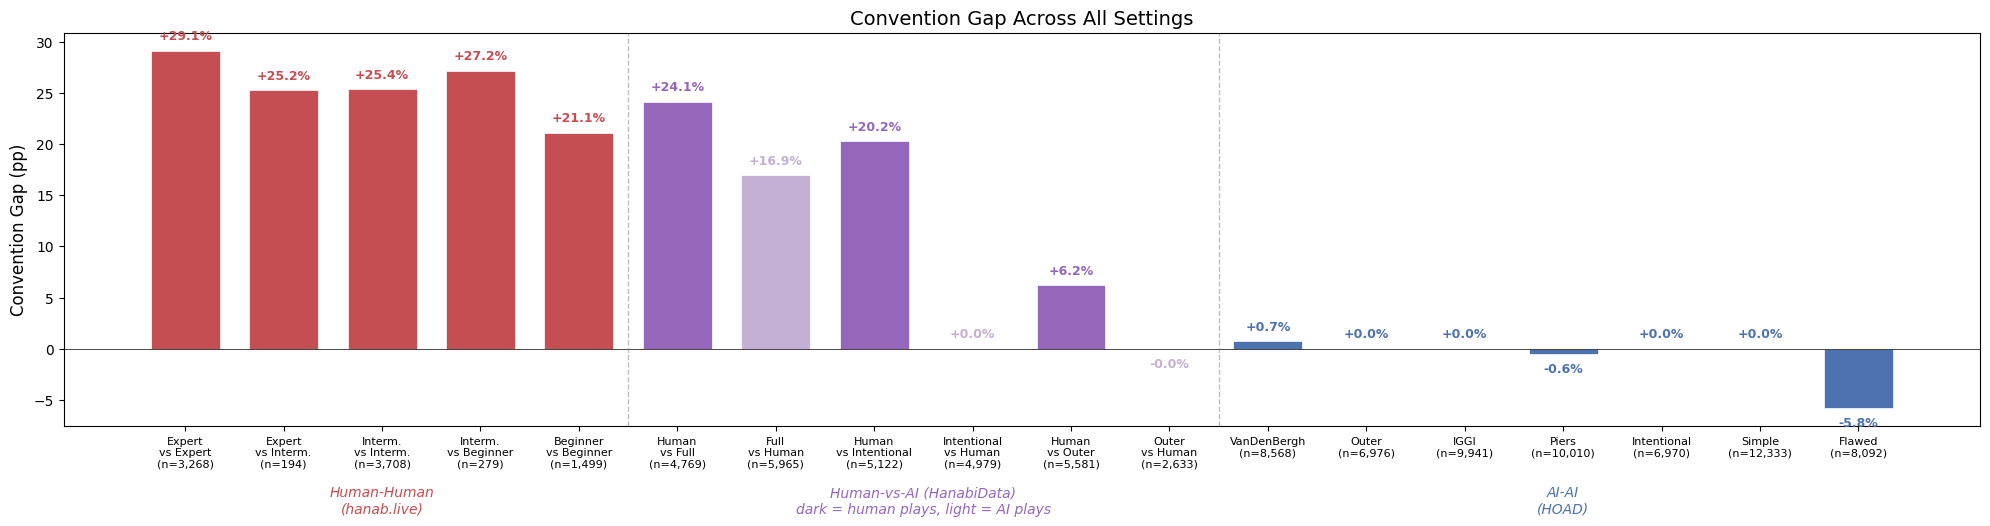

In [16]:
# Figure A3: Convention gap across all settings
# Includes paired bars for Human-vs-AI section: human plays (dark) + AI plays (light)

from src.analysis import display_name, add_individual_skill_columns

def _gap_n(sdf):
    sdf = sdf.copy()
    if "life_lost" not in sdf.columns:
        sdf["life_lost"] = (~sdf["was_playable"]).astype(int)
    gap = sdf["posterior_p_life_loss"].mean() - sdf["life_lost"].mean()
    return gap, len(sdf)

# --- Human-Human by pair type (same as original) ---
hh_df = human_df.copy()
if "pair_type" not in hh_df.columns:
    hh_df = add_individual_skill_columns(hh_df)

hh_groups = []
pair_order = [
    ("expert-expert", "Expert\nvs Expert"),
    ("expert-intermediate", "Expert\nvs Interm."),
    ("intermediate-intermediate", "Interm.\nvs Interm."),
    ("intermediate-beginner", "Interm.\nvs Beginner"),
    ("beginner-beginner", "Beginner\nvs Beginner"),
]
for pair_key, pair_label in pair_order:
    sub = hh_df[hh_df["pair_type"] == pair_key]
    if len(sub) == 0:
        continue
    gap, n = _gap_n(sub)
    hh_groups.append((f"{pair_label}\n(n={n:,})", gap, n))

# --- Human-vs-AI: paired bars (human plays + AI plays) ---
hai_human = human_ai_df[human_ai_df["subject_type"] == "human"].copy()
hai_groups = []
hai_colors_list = []
for ai in ["full", "intentional", "outer"]:
    # Human plays
    sub_h = hai_human[hai_human["partner_type"] == ai]
    gap_h, n_h = _gap_n(sub_h)
    hai_groups.append((f"Human\nvs {display_name(ai)}\n(n={n_h:,})", gap_h, n_h))
    hai_colors_list.append("#9467bd")  # dark purple

    # AI plays
    sub_a = human_ai_df[human_ai_df["subject_type"] == ai]
    gap_a, n_a = _gap_n(sub_a)
    hai_groups.append((f"{display_name(ai)}\nvs Human\n(n={n_a:,})", gap_a, n_a))
    hai_colors_list.append("#c5b0d5")  # light purple

# --- AI-AI by subject agent (same as original) ---
aa_groups = []
agent_order = ["bergh", "outer", "iggi", "piers", "internal", "simple", "flawed"]
for agent_key in agent_order:
    sub = agent_df[agent_df["subject_type"] == agent_key]
    if len(sub) == 0:
        continue
    gap, n = _gap_n(sub)
    aa_groups.append((f"{display_name(agent_key)}\n(n={n:,})", gap, n))

# Combine all bars
all_groups = hh_groups + hai_groups + aa_groups
labels = [g[0] for g in all_groups]
values = [g[1] for g in all_groups]

n_hh = len(hh_groups)
n_hai = len(hai_groups)  # now 6
n_aa = len(aa_groups)

colors = (["#c44e52"] * n_hh +
          hai_colors_list +
          ["#4c72b0"] * n_aa)

fig, ax = plt.subplots(figsize=(20, 6))
x = np.arange(len(labels))
bars = ax.bar(x, [v * 100 for v in values], color=colors, width=0.7,
              edgecolor="white", linewidth=0.5)

# Value labels
for bar, val in zip(bars, values):
    y = bar.get_height()
    va = "bottom" if y >= 0 else "top"
    offset = 0.8 if y >= 0 else -0.8
    color = bar.get_facecolor()
    ax.text(bar.get_x() + bar.get_width() / 2, y + offset,
            f"{val:+.1%}", ha="center", va=va,
            fontsize=9, fontweight="bold", color=color)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8, ha="center")
ax.set_ylabel("Convention Gap (pp)", fontsize=12)
ax.set_title("Convention Gap Across All Settings", fontsize=14)
ax.axhline(0, color="black", linewidth=0.5)

# Dashed separator lines
sep1 = n_hh - 0.5
sep2 = n_hh + n_hai - 0.5
for sep in [sep1, sep2]:
    ax.axvline(sep, color="gray", linestyle="--", linewidth=1, alpha=0.5)

# Source labels below x-axis
trans = ax.get_xaxis_transform()
ax.text((n_hh - 1) / 2, -0.22, "Human-Human\n(hanab.live)",
        ha="center", fontsize=10, color="#c44e52", style="italic",
        transform=trans)
ax.text(n_hh + (n_hai - 1) / 2, -0.22,
        "Human-vs-AI (HanabiData)\ndark = human plays, light = AI plays",
        ha="center", fontsize=10, color="#9467bd", style="italic",
        transform=trans)
ax.text(n_hh + n_hai + (n_aa - 1) / 2, -0.22, "AI-AI\n(HOAD)",
        ha="center", fontsize=10, color="#4c72b0", style="italic",
        transform=trans)

fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
fig.savefig("../output/figures/convention_gap_all_settings.png", dpi=150)
print("Saved convention_gap_all_settings.png")
plt.show()


---
## Appendix K — Game Score Analysis (Figure A4, Figure A5)

Mean game scores across all settings and score distributions by AI partner.

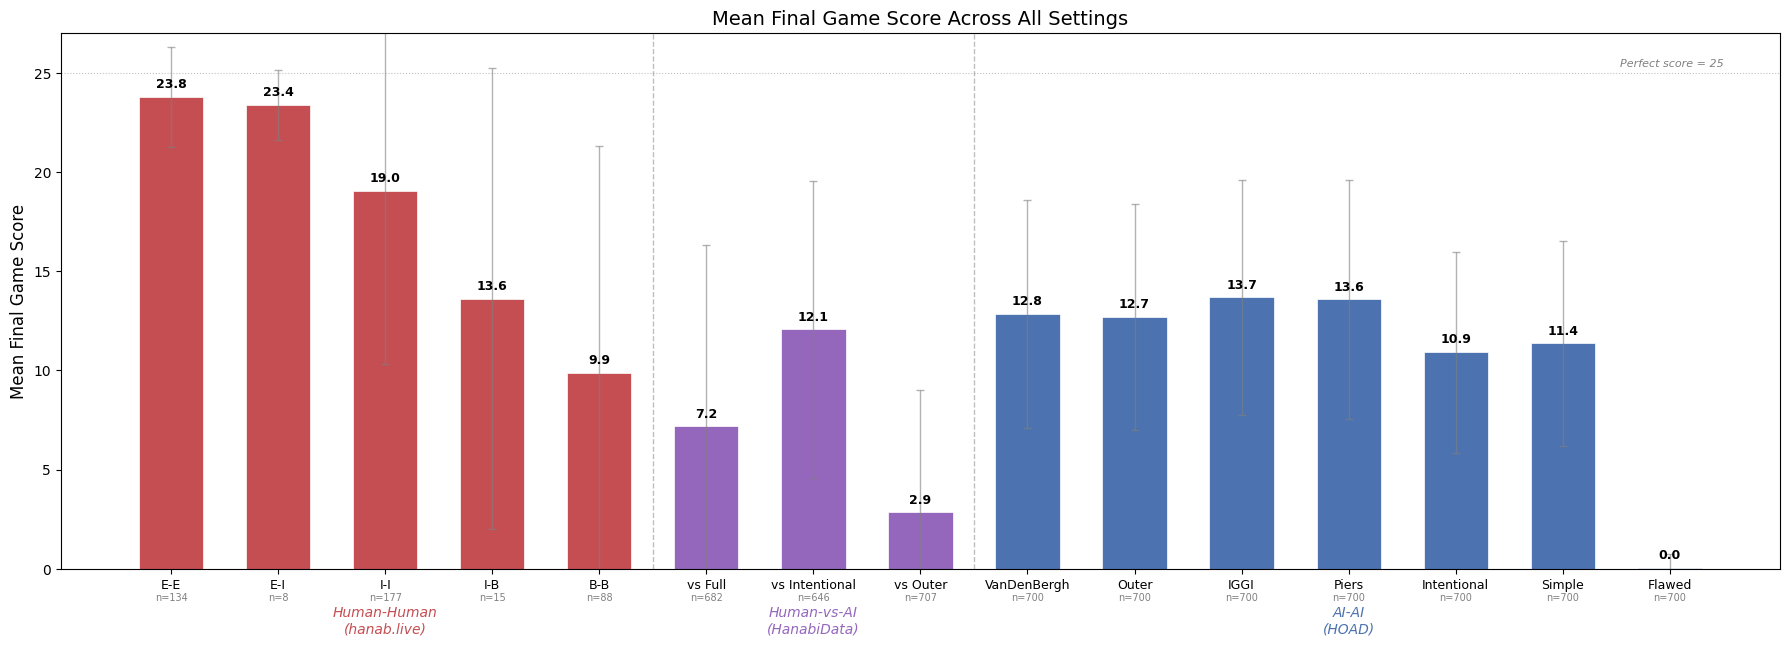

In [5]:
fig_a3 = plot_game_scores_all_settings(human_df, agent_df, human_ai_df)
plt.show()

In [6]:
# Game score ANOVAs (between and within category)
def get_game_scores(df, group_col, group_val):
    sub = df[df[group_col] == group_val]
    return sub.groupby('game_key')['final_score'].first().values

categories = {}

# Human-Human
hh_labels, hh_scores = [], []
for pair_key, pair_label in [('expert-expert', 'E-E'), ('expert-intermediate', 'E-I'),
                             ('expert-beginner', 'E-B'),
                             ('intermediate-intermediate', 'I-I'), ('intermediate-beginner', 'I-B'),
                             ('beginner-beginner', 'B-B')]:
    scores = get_game_scores(human_df, 'pair_type', pair_key)
    if len(scores) > 0:
        hh_labels.append(pair_label)
        hh_scores.append(scores)
categories['Human-Human'] = (hh_labels, hh_scores)

# Human-vs-AI
hai_labels, hai_scores = [], []
for ai, label in [('full', 'vs Full'), ('intentional', 'vs Intentional'), ('outer', 'vs Outer')]:
    sub = human_ai_df[human_ai_df['partner_type'] == ai]
    scores = sub.groupby('game_key')['final_score'].first().values
    if len(scores) > 0:
        hai_labels.append(label)
        hai_scores.append(scores)
categories['Human-vs-AI'] = (hai_labels, hai_scores)
print(f"Human-AI within-ANOVA unit: {sum(len(s) for s in hai_scores):,} games containing a human play")

# AI-AI — unique-game unit: each of the 4,900 games assigned to the
# first-named agent of its pairing file (moves first); 700 games per agent
first_mover = agent_df['game_key'].str.split(':').str[0].str.split('_vs_').str[0]
aa_labels, aa_scores = [], []
for agent_key in ['bergh', 'outer', 'iggi', 'piers', 'internal', 'simple', 'flawed']:
    scores = agent_df[first_mover == agent_key].groupby('game_key')['final_score'].first().values  # 700
    if len(scores) > 0:
        aa_labels.append(display_name(agent_key))
        aa_scores.append(scores)
categories['AI-AI'] = (aa_labels, aa_scores)
print(f"AI-AI unit: first-named agent of pairing file; games per agent = "
      f"{sorted(set(len(s) for s in aa_scores))}, total = {sum(len(s) for s in aa_scores):,} "
      f"(each game counted once)")

# Between-category ANOVA (T5: AI-AI on UNIQUE games, not subject-game unit)
print('=' * 70)
print('BETWEEN-CATEGORY ANOVA: Game Score ~ Category')
print('=' * 70)
cat_pools = {}
for cat_name, (labels, scores_list) in categories.items():
    if cat_name == 'AI-AI':
        # Use unique game_keys (one score per game) rather than per-subject observations
        cat_pools[cat_name] = agent_df.groupby('game_key')['final_score'].first().values
    elif cat_name == 'Human-vs-AI':
        # Use ALL plays (2,040 unique games, incl. the 5 games with no human plays)
        cat_pools[cat_name] = human_ai_df.groupby('game_key')['final_score'].first().values
    elif cat_name == 'Human-Human':
        # Include E-B games: pool over ALL games in the H-H corpus, not the per-pair-type list
        cat_pools[cat_name] = human_df.groupby('game_key')['final_score'].first().values
    else:
        cat_pools[cat_name] = np.concatenate(scores_list)

for cat_name, pool in cat_pools.items():
    print(f'  {cat_name:<15} n={len(pool):>5,}  mean={pool.mean():.1f}  SD={pool.std():.1f}')

f_stat, p_val = stats.f_oneway(*cat_pools.values())
n_total = sum(len(v) for v in cat_pools.values())
k = len(cat_pools)
print(f'\n  F({k-1}, {n_total-k}) = {f_stat:.2f}, p = {p_val:.2e}')

result_cat = tukey_hsd(*cat_pools.values())
cat_names = list(cat_pools.keys())
print(f'\n  Tukey HSD:')
for i in range(len(cat_names)):
    for j in range(i+1, len(cat_names)):
        pv = result_cat.pvalue[i][j]
        sig = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else 'ns'
        diff = cat_pools[cat_names[i]].mean() - cat_pools[cat_names[j]].mean()
        print(f'    {cat_names[i]} vs {cat_names[j]}: diff={diff:+.1f}, p={pv:.4f} {sig}')

# Within-category ANOVAs
for cat_name, (labels, scores_list) in categories.items():
    print(f'\n{"=" * 70}')
    print(f'WITHIN {cat_name.upper()} ANOVA: Game Score ~ Subgroup')
    print(f'{"=" * 70}')
    print(f'  {"Group":<18} {"N":>6} {"Mean":>8} {"SD":>8}')
    print(f'  {"-" * 44}')
    for lbl, sc in zip(labels, scores_list):
        print(f'  {lbl:<18} {len(sc):>6} {sc.mean():>8.1f} {sc.std():>8.1f}')
    if len(scores_list) >= 2:
        f_stat, p_val = stats.f_oneway(*scores_list)
        n_t = sum(len(g) for g in scores_list)
        k_g = len(scores_list)
        print(f'\n  F({k_g-1}, {n_t-k_g}) = {f_stat:.2f}, p = {p_val:.2e}')
        result = tukey_hsd(*scores_list)
        print(f'\n  Tukey HSD pairwise comparisons:')
        header = '  ' + ' ' * 18 + ''.join(f'{lbl:>18}' for lbl in labels)
        print(header)
        for i, lbl_i in enumerate(labels):
            row_str = '  ' + f'{lbl_i:>18}'
            for j in range(len(labels)):
                if i == j:
                    row_str += ' ' * 17 + '\u2014'
                else:
                    pv = result.pvalue[i][j]
                    sig = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else 'ns'
                    cell = f'{pv:.3f} {sig:>3s}'
                    row_str += cell.rjust(18)
            print(row_str)


Human-AI within-ANOVA unit: 2,035 games containing a human play
AI-AI unit: first-named agent of pairing file; games per agent = [700], total = 4,900 (each game counted once)
BETWEEN-CATEGORY ANOVA: Game Score ~ Category
  Human-Human     n=  425  mean=18.5  SD=9.6
  Human-vs-AI     n=2,040  mean=7.2  SD=8.5
  AI-AI           n=4,900  mean=10.7  SD=6.9

  F(2, 7362) = 429.82, p = 2.81e-177

  Tukey HSD:
    Human-Human vs Human-vs-AI: diff=+11.3, p=0.0000 ***
    Human-Human vs AI-AI: diff=+7.8, p=0.0000 ***
    Human-vs-AI vs AI-AI: diff=-3.5, p=0.0000 ***

WITHIN HUMAN-HUMAN ANOVA: Game Score ~ Subgroup
  Group                   N     Mean       SD
  --------------------------------------------
  E-E                   134     23.8      2.5
  E-I                     8     23.4      1.7
  E-B                     3     16.7     11.8
  I-I                   177     19.0      8.7
  I-B                    15     13.6     11.2
  B-B                    88      9.9     11.4

  F(5, 419) = 32.


  Tukey HSD pairwise comparisons:
                               vs Full    vs Intentional          vs Outer
             vs Full                 —         0.000 ***         0.000 ***
      vs Intentional         0.000 ***                 —         0.000 ***
            vs Outer         0.000 ***         0.000 ***                 —

WITHIN AI-AI ANOVA: Game Score ~ Subgroup
  Group                   N     Mean       SD
  --------------------------------------------
  VanDenBergh           700     12.8      5.8
  Outer                 700     12.7      5.7
  IGGI                  700     13.7      5.9
  Piers                 700     13.6      6.0
  Intentional           700     10.9      5.1
  Simple                700     11.4      5.1
  Flawed                700      0.0      0.7

  F(6, 4893) = 601.39, p = 0.00e+00



  Tukey HSD pairwise comparisons:
                           VanDenBergh             Outer              IGGI             Piers       Intentional            Simple            Flawed
         VanDenBergh                 —         0.996  ns         0.045   *         0.130  ns         0.000 ***         0.000 ***         0.000 ***
               Outer         0.996  ns                 —         0.006  **         0.023   *         0.000 ***         0.000 ***         0.000 ***
                IGGI         0.045   *         0.006  **                 —         1.000  ns         0.000 ***         0.000 ***         0.000 ***
               Piers         0.130  ns         0.023   *         1.000  ns                 —         0.000 ***         0.000 ***         0.000 ***
         Intentional         0.000 ***         0.000 ***         0.000 ***         0.000 ***                 —         0.704  ns         0.000 ***
              Simple         0.000 ***         0.000 ***         0.000 ***         

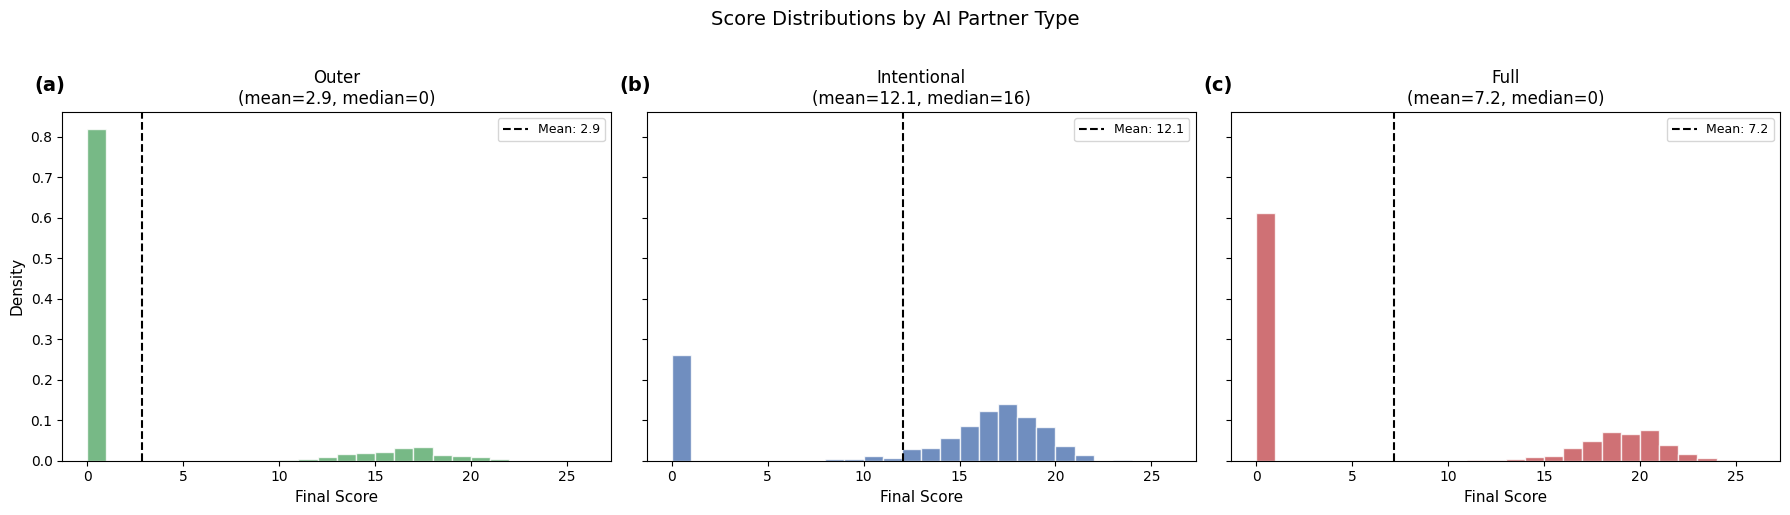

In [19]:
fig_a4 = plot_score_distributions(human_ai_df)
plt.show()

---
## Appendix M — Game Score Analysis: censoring diagnostic (lenient end score)

Does the zero-spike/high-hump bimodality in Fig 1a come from three-strike censoring or from population mixture? The *lenient end score* (score at the moment of failure — the older human-subject scoring convention, e.g. Eger 2017; this is the quantity the code calls the "uncensored" score) keeps the official score for natural/perfect games and uses the pre-strike tableau total for struck games (`fireworks_sum + was_playable` on the last play record). This is the Camp B / **lenient** convention; the paper's headline numbers use the **strict** / Camp A rule (three strikes → 0, HLE-aligned: Bard et al. 2020; Jeon & Kim 2023; AH2AC2; Chi 2026). Verification targets — lenient bin %: H-H 0/4/10/4/10/72, H-AI 1/16/22/24/33/3, AI-AI 2/19/10/41/27/1; struck-game pre-strike means 8.9 / 8.4 / 3.4; lenient means (SD) 20.31 (6.5) / 12.07 (5.7) / 11.63 (5.6) for H-H / H-AI / AI-AI; Welch H-AI vs AI-AI lenient t=2.94 (sign reversed vs strict −3.5), H-H vs H-AI t=24.4.

setting           0     1-5    6-10   11-15   16-20   21-25   struck-mean (n)
Human-Human       0       4      10       4      10      72   8.9 (n=87)
Human-AI          1      16      22      24      33       3   8.4 (n=1170)
AI-AI             2      19      10      41      27       1   3.4 (n=1289)

Official (zeroed) bin % for comparison:
  Human-Human  [20, 0, 0, 0, 8, 71]
  Human-AI     [57, 0, 1, 10, 29, 3]
  AI-AI        [26, 0, 6, 40, 27, 1]

Lenient vs strict end-score means (SD) and strict-zero fraction:
  Human-Human  lenient 20.31 (SD 6.47) | strict 18.52 (SD 9.57) | strict-0 20.5%
  Human-AI     lenient 12.07 (SD 5.71) | strict 7.22 (SD 8.55) | strict-0 57.4%
  AI-AI        lenient 11.63 (SD 5.62) | strict 10.73 (SD 6.86) | strict-0 26.3%
  Welch lenient H-AI vs AI-AI: t=2.94, p=0.0033, d=0.078 (strict was t=-16.45 -> sign reversed)
  Welch lenient H-H vs H-AI:  t=24.38, p=1.84e-90, d=1.352


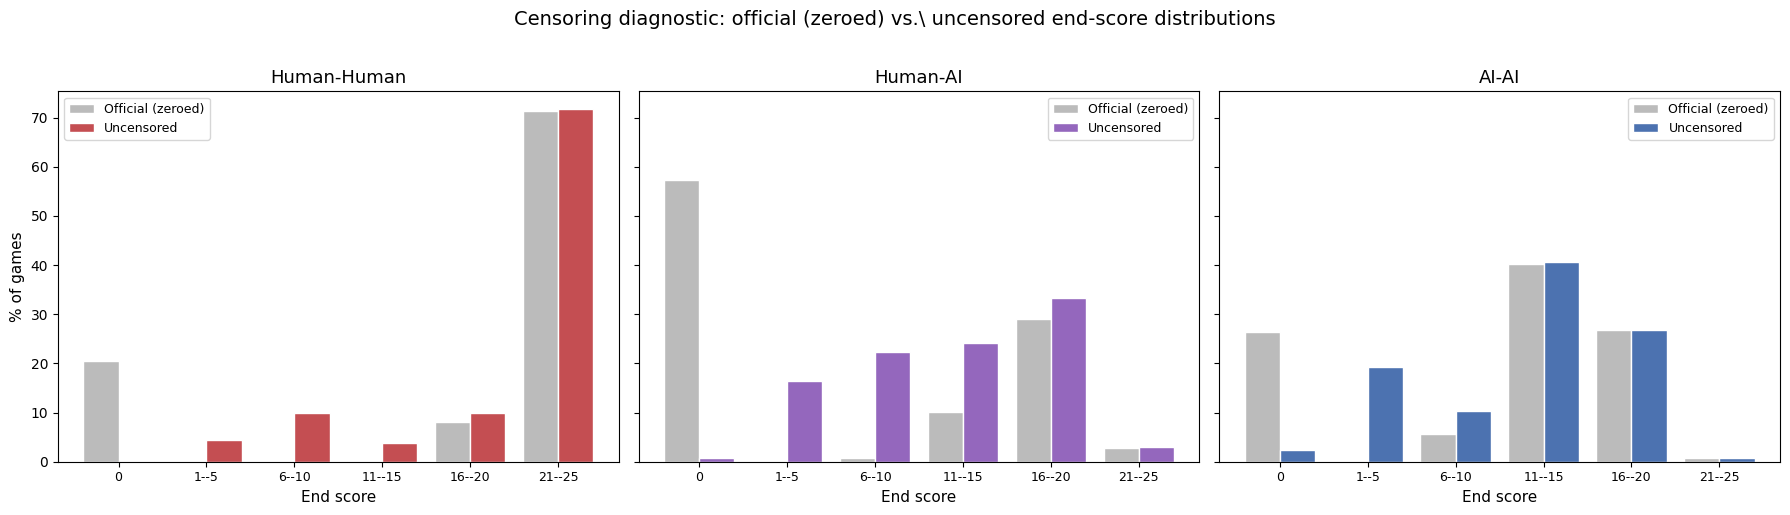

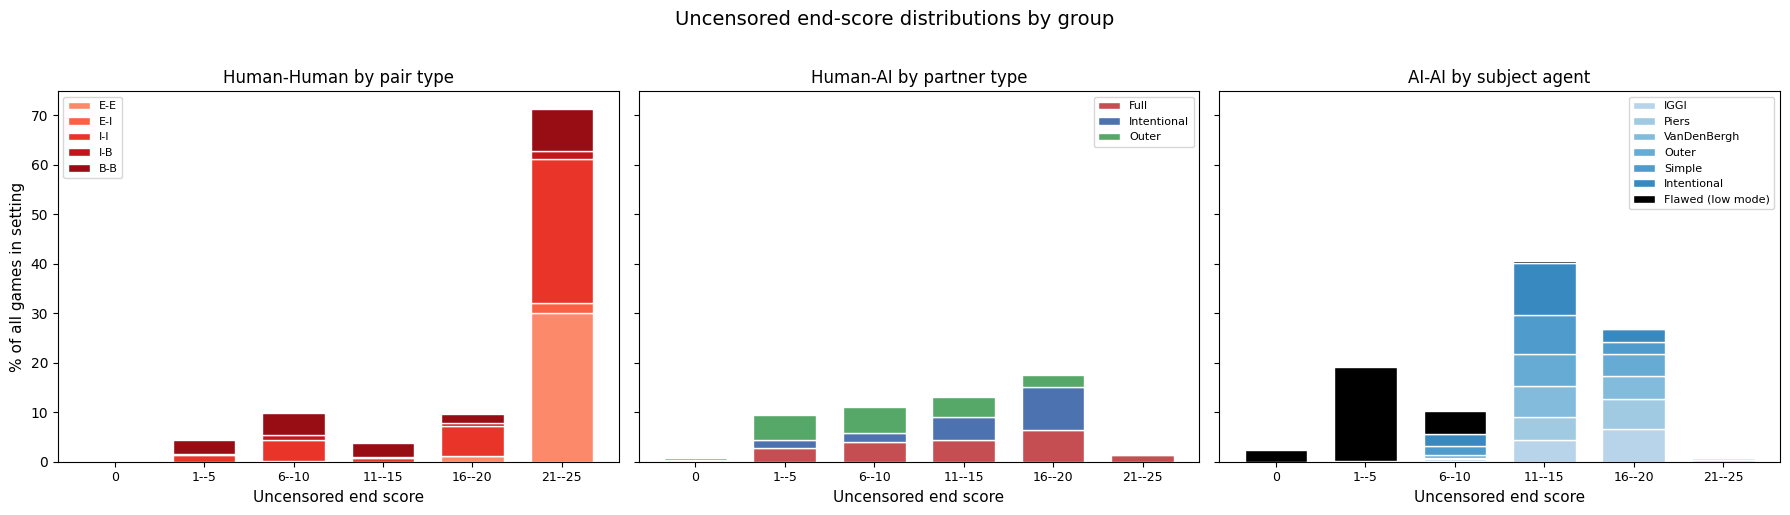

In [20]:
from src.analysis import plot_uncensored_score_diagnostic, lenient_score_stats

unc = plot_uncensored_score_diagnostic(human_df, agent_df, human_ai_df)
bins = ['0','1-5','6-10','11-15','16-20','21-25']
print(f"{'setting':<12} {'  '.join(f'{b:>6}' for b in bins)}   struck-mean (n)")
for name, r in unc.items():
    row = '  '.join(f'{v:>6}' for v in r['uncensored_bin_pct'])
    print(f"{name:<12} {row}   {r['struck_uncensored_mean']} (n={r['n_struck']})")
print()
print('Official (zeroed) bin % for comparison:')
for name, r in unc.items():
    print(f"  {name:<12} {r['official_bin_pct']}")
print()

# Lenient (= uncensored) end-score means and Welch tests (Appendix M / Fig 1a)
ls = lenient_score_stats(human_df, agent_df, human_ai_df)
print('Lenient vs strict end-score means (SD) and strict-zero fraction:')
for name in ['Human-Human','Human-AI','AI-AI']:
    r = ls[name]
    print(f"  {name:<12} lenient {r['lenient_mean']:.2f} (SD {r['lenient_sd']:.2f}) | "
          f"strict {r['strict_mean']:.2f} (SD {r['strict_sd']:.2f}) | strict-0 {r['zero_frac_pct']:.1f}%")
tt = ls['tests']
print(f"  Welch lenient H-AI vs AI-AI: t={tt['lenient_HAI_vs_AA']['t']}, "
      f"p={tt['lenient_HAI_vs_AA']['p']:.4f}, d={tt['lenient_HAI_vs_AA']['d']} "
      f"(strict was t={tt['strict_HAI_vs_AA']['t']} -> sign reversed)")
print(f"  Welch lenient H-H vs H-AI:  t={tt['lenient_HH_vs_HAI']['t']}, "
      f"p={tt['lenient_HH_vs_HAI']['p']:.2e}, d={tt['lenient_HH_vs_HAI']['d']}")
plt.show()

---
## Appendix L — Cross-Play Heatmaps (Figure A6)

7x7 AI agent pairings: mean P(life lost) and mean game score.

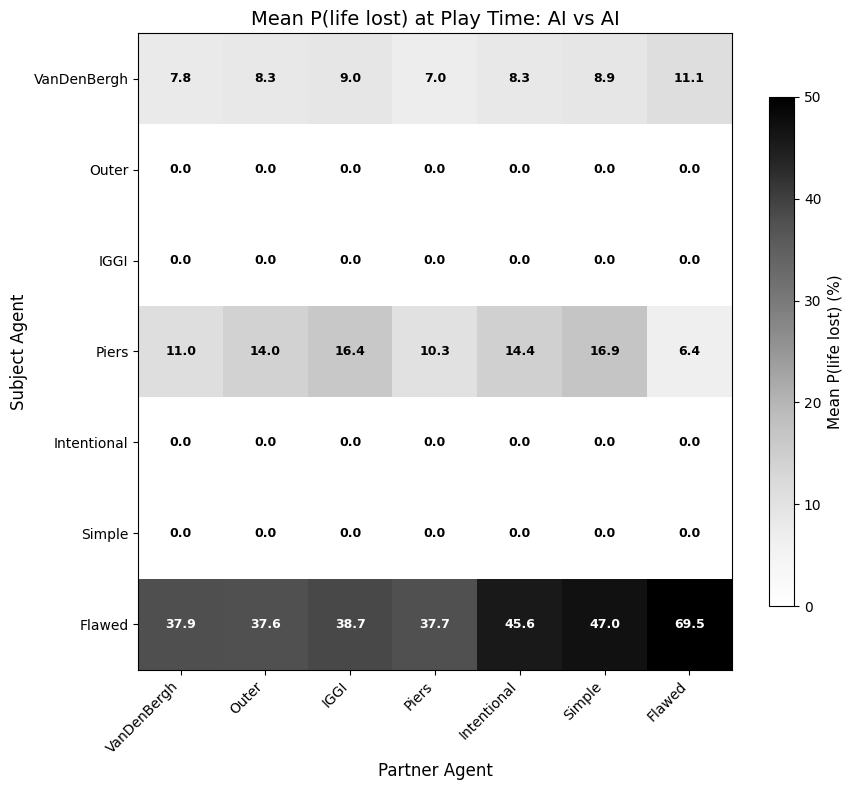

In [21]:
fig_a5 = plot_crossplay_posterior_heatmap(agent_df)
plt.show()

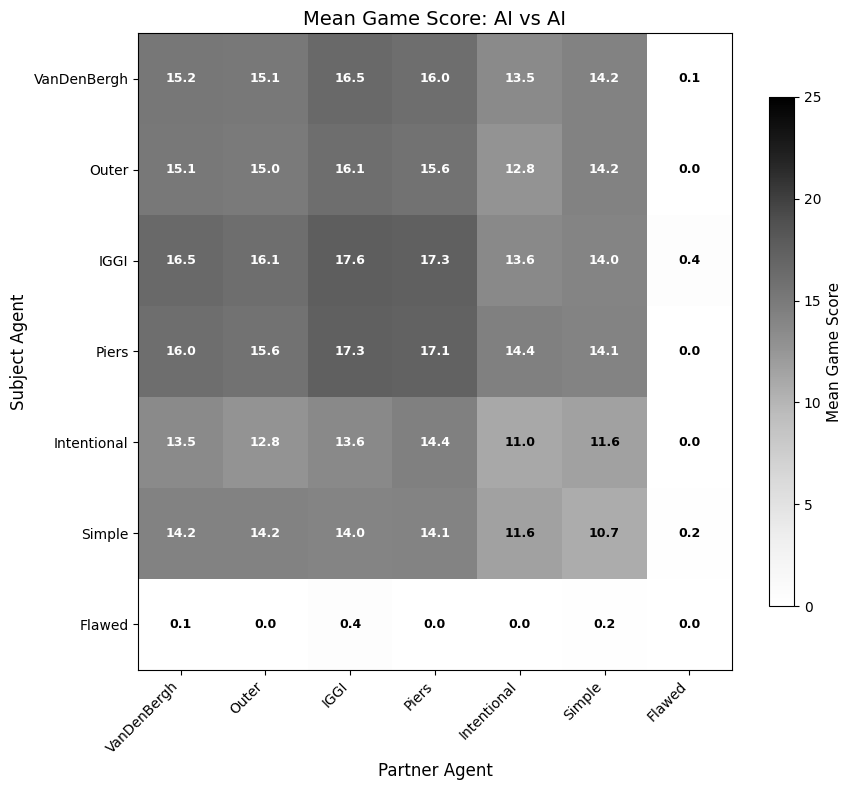

In [3]:
fig_a6 = plot_crossplay_score_heatmap(agent_df)
plt.show()

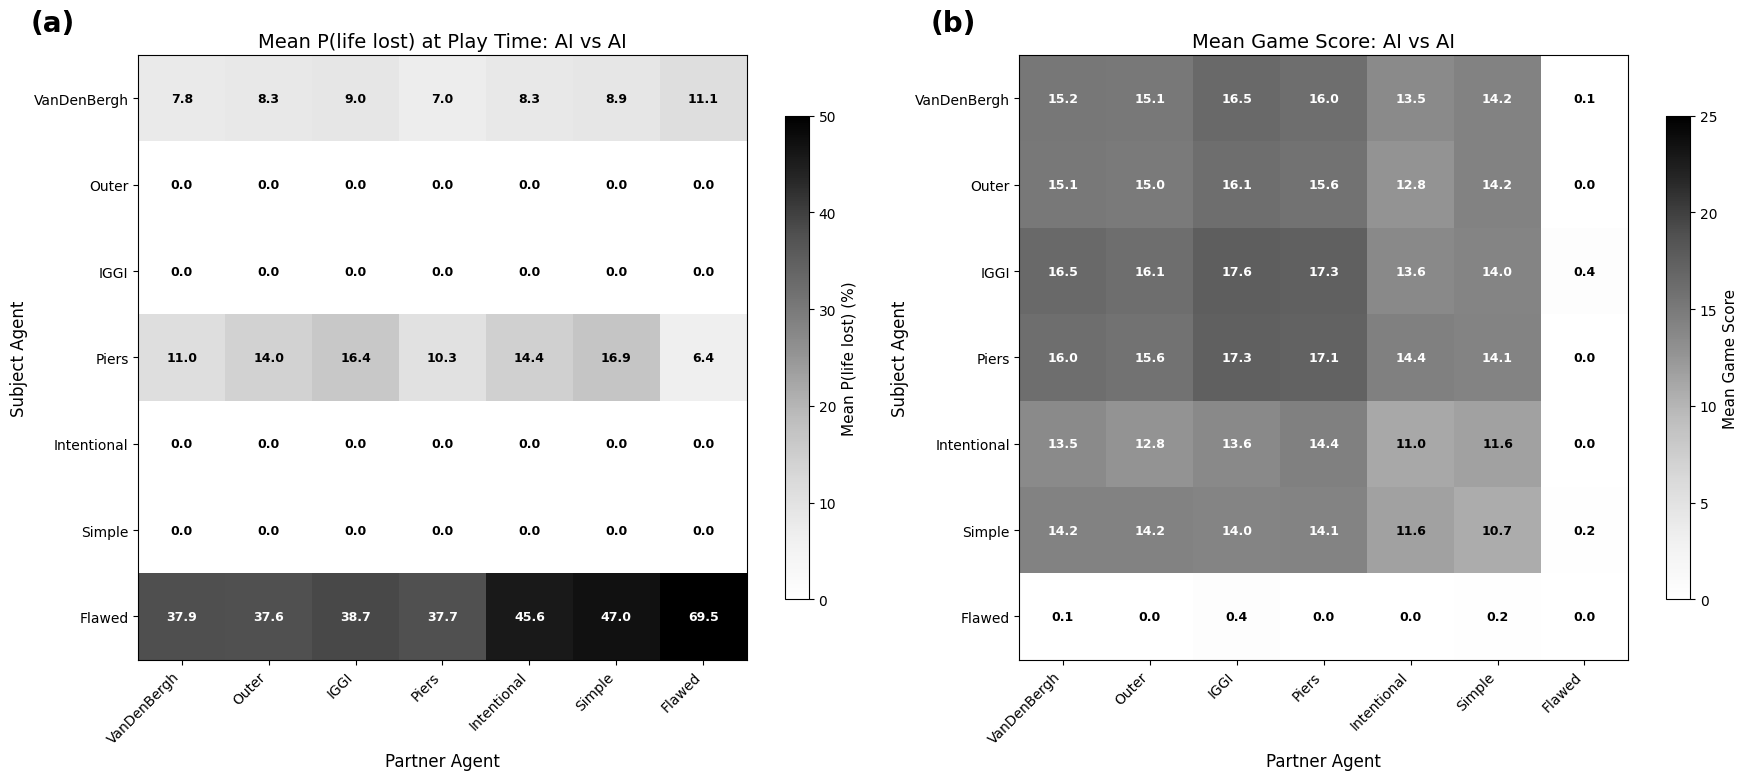

In [4]:
# Combined two-panel figure used as Figure A6 in the manuscript
# (saves Manuscript/figures/crossplay_combined.png via the shared
# output directory used by the individual panel functions above).
fig_a6_combined = plot_crossplay_combined(agent_df)
plt.show()

---
## Appendix L (cont.) — Convention Gap Cross-Matrices

7x7 AI-AI and 3x3 Human-Human subject x partner matrices.

In [24]:
# AI-AI 7x7 matrix
agent_order = ['bergh', 'outer', 'iggi', 'piers', 'internal', 'simple', 'flawed']

rows_aa = []
for subj in agent_order:
    row = {'Subject': display_name(subj)}
    for part in agent_order:
        sub = agent_df[(agent_df['subject_type'] == subj) & (agent_df['partner_type'] == part)]
        if len(sub) > 0:
            gap = sub['posterior_p_life_loss'].mean() - sub['life_lost'].mean()
            row[display_name(part)] = f'{gap*100:+.1f}  (n={len(sub):,})'
        else:
            row[display_name(part)] = '\u2014'
    rows_aa.append(row)

matrix_aa = pd.DataFrame(rows_aa).set_index('Subject')
print('AI-AI Convention Gap Matrix (pp): Subject (rows) x Partner (columns)')
print(matrix_aa.to_string())

AI-AI Convention Gap Matrix (pp): Subject (rows) x Partner (columns)
                 VanDenBergh            Outer             IGGI            Piers      Intentional           Simple         Flawed
Subject                                                                                                                         
VanDenBergh  +0.8  (n=1,634)  +2.3  (n=1,818)  +0.5  (n=1,580)  +0.6  (n=1,707)  -0.2  (n=1,455)    -2.9  (n=298)   +1.9  (n=76)
Outer        +0.0  (n=1,315)  +0.0  (n=1,498)  +0.0  (n=1,259)  +0.0  (n=1,493)  +0.0  (n=1,088)    +0.0  (n=290)   +0.0  (n=33)
IGGI         +0.0  (n=1,862)  +0.0  (n=1,951)  +0.0  (n=1,756)  +0.0  (n=2,032)  +0.0  (n=1,552)    +0.0  (n=713)   +0.0  (n=75)
Piers        -1.1  (n=1,828)  -0.2  (n=1,907)  +1.4  (n=1,691)  +0.4  (n=1,901)  -1.8  (n=1,687)    -3.5  (n=943)   +2.6  (n=53)
Intentional  +0.0  (n=1,365)  +0.0  (n=1,464)  +0.0  (n=1,163)  +0.0  (n=1,463)  +0.0  (n=1,100)    +0.0  (n=384)   +0.0  (n=31)
Simple       +0.0  (n=2,570)

In [25]:
import json

# Human-Human 3x3 matrix (derive partner_skill per record)
player_skills = human_df.groupby('player')['individual_skill'].first().to_dict()
game_players = human_df.groupby('game_key')['player'].apply(lambda x: list(x.unique())).to_dict()

def get_partner_skill(row):
    players = game_players.get(row['game_key'], [])
    partners = [p for p in players if p != row['player']]
    if partners:
        return player_skills.get(partners[0], row['individual_skill'])
    pair = row.get('pair_type', '')
    parts = pair.split('-')
    if len(parts) == 2:
        if parts[0] != row['individual_skill']:
            return parts[0]
        elif parts[1] != row['individual_skill']:
            return parts[1]
    return row['individual_skill']

human_df['partner_skill'] = human_df.apply(get_partner_skill, axis=1)

# All mixed-skill games are already in human_df (B2 audit: cell-37 side-loading removed).
combined = human_df[['posterior_p_life_loss', 'life_lost', 'individual_skill', 'partner_skill']].copy()
combined['posterior_p_life_loss'] = pd.to_numeric(combined['posterior_p_life_loss'])
combined['life_lost'] = pd.to_numeric(combined['life_lost'])
print(f'Play records:  {len(combined):,}\n')

skills = ['expert', 'intermediate', 'beginner']
rows_hh = []
for subj in skills:
    row = {'Subject': subj.capitalize()}
    for part in skills:
        sub = combined[(combined['individual_skill'] == subj) & (combined['partner_skill'] == part)]
        if len(sub) > 0:
            gap = sub['posterior_p_life_loss'].mean() - sub['life_lost'].mean()
            actual = sub['life_lost'].mean()
            row[part.capitalize()] = f'{gap*100:+.1f}pp  (loss={actual:.1%}, n={len(sub):,})'
        else:
            row[part.capitalize()] = '\u2014 (no data)'
    rows_hh.append(row)

matrix_hh = pd.DataFrame(rows_hh).set_index('Subject')
print('Human-Human Convention Gap Matrix: Subject Skill (rows) x Partner Skill (columns)')
print(matrix_hh.to_string())

Play records:  9,017

Human-Human Convention Gap Matrix: Subject Skill (rows) x Partner Skill (columns)
                                     Expert                   Intermediate                        Beginner
Subject                                                                                                   
Expert        +29.1pp  (loss=2.5%, n=3,268)     +25.9pp  (loss=4.4%, n=90)      +34.9pp  (loss=7.1%, n=28)
Intermediate    +24.7pp  (loss=2.9%, n=104)  +25.4pp  (loss=4.8%, n=3,708)     +28.1pp  (loss=9.7%, n=155)
Beginner         +40.2pp  (loss=2.4%, n=41)    +26.1pp  (loss=8.1%, n=124)  +21.1pp  (loss=12.0%, n=1,499)


---
## Appendix M — Failure Mode Taxonomy (Table A7)

In [26]:
hh_classified = classify_failures(human_df)
hai_classified = classify_failures(hai_human)

categories_fail = ['blind_play', 'misread_hint', 'calculated_risk', 'desperate_play', 'convention_failure']
cat_labels = ['Blind play (0 hints, P>0.5)', 'Misread hint (1+ hints, P: 0.1-0.5)',
              'Calculated risk (1+ hints, P<0.1)', 'Desperate play (1 life left)',
              'Convention failure (1+ hints, P>0.5)']

def failure_dist(df):
    failures = df[df['failure_category'] != 'success']
    total = len(failures)
    dist = {}
    for cat in categories_fail:
        dist[cat] = (failures['failure_category'] == cat).sum() / total * 100 if total > 0 else 0
    dist['total'] = total
    return dist

hh_dist = failure_dist(hh_classified)
full_dist = failure_dist(hai_classified[hai_classified['partner_type'] == 'full'])
intent_dist = failure_dist(hai_classified[hai_classified['partner_type'] == 'intentional'])
outer_dist = failure_dist(hai_classified[hai_classified['partner_type'] == 'outer'])

print('Table A3: Failure Category Distribution (% of total failures)')
print(f'{"Category":<45} {"H-H":>6} {"vs Full":>8} {"vs Intent.":>10} {"vs Outer":>9}')
print('-' * 80)
for cat, label in zip(categories_fail, cat_labels):
    print(f'{label:<45} {hh_dist[cat]:>5.1f} {full_dist[cat]:>7.1f} {intent_dist[cat]:>9.1f} {outer_dist[cat]:>8.1f}')
print('-' * 80)
print(f'{"Total failures":<45} {hh_dist["total"]:>5,} {full_dist["total"]:>7,} {intent_dist["total"]:>9,} {outer_dist["total"]:>8,}')

# Cascade analysis
print('\n--- Cascade Analysis ---')
for ai_name in ['full', 'intentional', 'outer']:
    sub = hai_human[hai_human['partner_type'] == ai_name].copy()
    sub = sub.sort_values(['game_id', 'turn'])
    # Find turns where life was lost
    life_loss_turns = sub[sub['life_lost'] == 1][['game_id', 'turn']].values
    gaps_before, gaps_after = [], []
    for gid, turn in life_loss_turns:
        game = sub[sub['game_id'] == gid]
        before = game[(game['turn'] >= turn - 5) & (game['turn'] < turn)]
        after = game[(game['turn'] > turn) & (game['turn'] <= turn + 5)]
        if len(before) > 0:
            gaps_before.append(before['posterior_p_life_loss'].mean() - before['life_lost'].mean())
        if len(after) > 0:
            gaps_after.append(after['posterior_p_life_loss'].mean() - after['life_lost'].mean())
    if gaps_before and gaps_after:
        diff = np.mean(gaps_after) - np.mean(gaps_before)
        print(f'  {display_name(ai_name)}: gap drops {diff*100:+.1f}pp after life loss')

Table A3: Failure Category Distribution (% of total failures)
Category                                         H-H  vs Full vs Intent.  vs Outer
--------------------------------------------------------------------------------
Blind play (0 hints, P>0.5)                    17.4    12.2      24.5      3.4
Misread hint (1+ hints, P: 0.1-0.5)            24.4    12.7       9.9     14.9
Calculated risk (1+ hints, P<0.1)               0.0     0.3       0.2      0.1
Desperate play (1 life left)                   18.1    29.2      18.6     30.1
Convention failure (1+ hints, P>0.5)           39.5    45.2      46.3     51.4
--------------------------------------------------------------------------------
Total failures                                  476     686       903    1,921

--- Cascade Analysis ---


  Full: gap drops -4.3pp after life loss


  Intentional: gap drops -3.0pp after life loss


  Outer: gap drops -7.6pp after life loss


---
## Appendix N — Convention Learning (Table A8)

In [27]:
learning_results = analyze_convention_learning(human_df, human_ai_df, agent_df)



=== 8.3 Convention Learning Analysis ===

Players with 10+ games: 20
Positive slope (improving): 75.0% of players
Significant positive (p<0.05): 2
Significant negative (p<0.05): 1
Mean slope: +0.0037 per game
Median slope: +0.0019 per game

Mean learning rate by skill:
  beginner: +0.01090/game (n=5)
  intermediate: +0.00214/game (n=10)
  expert: -0.00025/game (n=5)

Mapped 15472/15472 HAI records to participants

Human-AI convention learning by AI partner type (pooled):
  vs full: slope=+0.000049/game, R²=0.0002, p=0.6822, n=682
  vs intentional: slope=-0.000250/game, R²=0.0072, p=0.0313, n=646
  vs outer: slope=-0.000020/game, R²=0.0001, p=0.8166, n=707

Human-vs-AI learning slopes (23 trials with 10+ games):
  Positive slope: 43.5%
  Significant positive (p<0.05): 0
  Significant negative (p<0.05): 0
  Mean slope: -0.001092
  By AI partner:
    vs full: 9 trials, mean slope=+0.001183
    vs intentional: 7 trials, mean slope=-0.002860
    vs outer: 7 trials, mean slope=-0.002248


### OLS Regression: Convention Learning with Continuous Skill Score

Tests whether convention learning (change in per-game convention gap over game history) depends on player skill level, using the player's average game score as a continuous variable rather than categorical skill bins.

**Model:** `convention_gap ~ skill_score + game_seq + skill_score:game_seq`

This is a more parsimonious specification than the categorical (beginner/intermediate/expert) version — BIC prefers the continuous model.

In [28]:
### OLS Regression: Convention Gap ~ Skill Score + Game Sequence + Interaction
#
# Uses continuous player average score instead of categorical skill level.
# Manual OLS implementation (no scipy/statsmodels dependency).

import numpy as np
import pandas as pd

hh = human_df.copy()
hh['life_lost'] = (~hh['was_playable']).astype(int)

# Compute player average scores
game_scores = hh.groupby('game_id')['final_score'].first().reset_index()
player_game_scores = hh[['game_id', 'player']].drop_duplicates().merge(game_scores, on='game_id')
player_avgs = player_game_scores.groupby('player')['final_score'].mean()
hh['player_avg_score'] = hh['player'].map(player_avgs)

# Per-game convention gap
game_stats = hh.groupby(['game_id', 'player', 'player_avg_score']).agg(
    mean_posterior=('posterior_p_life_loss', 'mean'),
    actual_loss_rate=('life_lost', 'mean'),
    n_plays=('life_lost', 'count')
).reset_index()
game_stats['convention_gap'] = game_stats['mean_posterior'] - game_stats['actual_loss_rate']
game_stats = game_stats.sort_values(['player', 'game_id'])
game_stats['game_seq'] = game_stats.groupby('player').cumcount()

# Filter to players with 10+ games
counts = game_stats.groupby('player').size()
gf = game_stats[game_stats['player'].isin(counts[counts >= 10].index)].copy()

print(f'Players with 10+ games: {gf["player"].nunique()}')
print(f'Total observations: {len(gf)}')
print(f'Player avg score range: {gf["player_avg_score"].min():.1f} \u2013 {gf["player_avg_score"].max():.1f}')
print()

# ---- OLS Implementation ----
y = gf['convention_gap'].values
n = len(y)
skill = gf['player_avg_score'].values
game_seq = gf['game_seq'].values.astype(float)

# Center skill for interpretability
skill_mean = skill.mean()
skill_c = skill - skill_mean

def ols_fit(X, y):
    """OLS regression: returns (beta, se, t, SS_res, df_res)."""
    XtX = X.T @ X
    beta = np.linalg.solve(XtX, X.T @ y)
    resid = y - X @ beta
    ss_res = np.sum(resid**2)
    df_res = len(y) - X.shape[1]
    mse = ss_res / df_res
    se = np.sqrt(np.diag(mse * np.linalg.inv(XtX)))
    t = beta / se
    return beta, se, t, ss_res, df_res

def normal_p(t_val):
    """Two-tailed p-value using normal approximation (Abramowitz & Stegun)."""
    x = abs(t_val) / np.sqrt(2)
    a1, a2, a3, a4, a5 = 0.254829592, -0.284496736, 1.421413741, -1.453152027, 1.061405429
    t_param = 1.0 / (1.0 + 0.3275911 * abs(x))
    erf = 1.0 - (a1*t_param + a2*t_param**2 + a3*t_param**3 + a4*t_param**4 + a5*t_param**5) * np.exp(-x**2)
    return max(1.0 - erf, 1e-16)

# Full model: gap ~ skill_c + game_seq + skill_c:game_seq
X_full = np.column_stack([np.ones(n), skill_c, game_seq, skill_c * game_seq])
beta, se, t_vals, ss_full, df_full = ols_fit(X_full, y)

params = ['Intercept (at mean skill)', 'Skill score (centered)',
          'Game sequence', 'Skill \u00d7 Game sequence']

print('=' * 78)
print(f'OLS: convention_gap ~ skill_score + game_seq + skill_score:game_seq')
print(f'Skill score centered at mean = {skill_mean:.2f}')
print(f'n = {n} game-player observations, {gf["player"].nunique()} players')
print('=' * 78)
print(f'{"Parameter":<30} {"Coef":>10} {"SE":>10} {"t":>8} {"p":>10}')
print('-' * 78)
for name, b, s, t in zip(params, beta, se, t_vals):
    p = normal_p(t)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f'{name:<30} {b:>+10.6f} {s:>10.6f} {t:>+8.3f} {p:>10.4f} {sig}')

# R-squared
ss_total = np.sum((y - y.mean())**2)
r2 = 1 - ss_full / ss_total
r2_adj = 1 - (ss_full / df_full) / (ss_total / (n - 1))
print(f'\nR\u00b2 = {r2:.4f}, Adjusted R\u00b2 = {r2_adj:.4f}')

# F-tests via nested model comparisons
X_null = np.ones((n, 1))
X_add = np.column_stack([np.ones(n), skill_c, game_seq])
X_skill = np.column_stack([np.ones(n), skill_c])
X_seq = np.column_stack([np.ones(n), game_seq])

_, _, _, ss_null, df_null = ols_fit(X_null, y)
_, _, _, ss_add, df_add = ols_fit(X_add, y)
_, _, _, ss_skill, df_skill = ols_fit(X_skill, y)
_, _, _, ss_seq, df_seq = ols_fit(X_seq, y)

f_overall = ((ss_null - ss_full) / 3) / (ss_full / df_full)
f_skill = ((ss_seq - ss_add) / 1) / (ss_add / df_add)
f_seq = ((ss_skill - ss_add) / 1) / (ss_add / df_add)
f_inter = ((ss_add - ss_full) / 1) / (ss_full / df_full)

print(f'\n{"F-test":<45} {"F":>8} {"df1":>4} {"df2":>6}')
print('-' * 70)
for name, f, d1, d2 in [
    ('Overall model', f_overall, 3, df_full),
    ('Skill (controlling for game_seq)', f_skill, 1, df_add),
    ('Game_seq (controlling for skill)', f_seq, 1, df_add),
    ('Interaction (skill \u00d7 game_seq)', f_inter, 1, df_full),
]:
    print(f'  {name:<43} {f:>8.3f} ({d1},{d2:>5})')

# Implied learning rates at representative skill levels
print(f'\nImplied learning rates (convention gap change per game):')
for score in [10, 15, 20, 25]:
    slope = beta[2] + beta[3] * (score - skill_mean)
    print(f'  avg_score = {score}: {slope:+.6f}/game')

# Model comparison: continuous vs categorical
skill_cat_map = {p: ('beginner' if s < 15 else ('intermediate' if s < 22 else 'expert'))
                 for p, s in player_avgs.items()}
skill_cat = gf['player'].map(skill_cat_map)
is_beg = (skill_cat == 'beginner').astype(float).values
is_exp = (skill_cat == 'expert').astype(float).values
X_cat = np.column_stack([np.ones(n), is_beg, is_exp, game_seq,
                         is_beg * game_seq, is_exp * game_seq])
_, _, _, ss_cat, df_cat = ols_fit(X_cat, y)
r2_cat = 1 - ss_cat / ss_total

bic_cont = n * np.log(ss_full / n) + 4 * np.log(n)
bic_cat = n * np.log(ss_cat / n) + 6 * np.log(n)

print(f'\nModel comparison:')
print(f'  Continuous: R\u00b2 = {r2:.4f}, BIC = {bic_cont:.1f} (4 parameters)')
print(f'  Categorical: R\u00b2 = {r2_cat:.4f}, BIC = {bic_cat:.1f} (6 parameters)')
print(f'  \u0394BIC = {bic_cont - bic_cat:+.1f} ({"continuous" if bic_cont < bic_cat else "categorical"} preferred)')

print(f'\n--- Summary ---')
def _sig_label(p):
    if p < 0.001: return 'p < 0.001'
    if p < 0.01:  return f'p = {p:.3f}'
    if p < 0.05:  return f'p = {p:.3f}'
    return f'p = {p:.3f} (n.s.)'
_p1, _p2, _p3 = normal_p(t_vals[1]), normal_p(t_vals[2]), normal_p(t_vals[3])
print(f'Skill main effect: t = {t_vals[1]:+.1f}, {_sig_label(_p1)}')
print(f'Learning trend: t = {t_vals[2]:+.1f}, {_sig_label(_p2)}')
print(f'Interaction: t = {t_vals[3]:+.1f}, {_sig_label(_p3)}')

# Export fit statistics so cell 45 does not have to hardcode them
hh_gameseq_coef = float(beta[2])
hh_gameseq_se = float(se[2])
hh_gameseq_t = float(t_vals[2])
hh_gameseq_p = float(_p2)
hh_n = int(n)


Players with 10+ games: 20
Total observations: 415
Player avg score range: 11.5 – 23.5

OLS: convention_gap ~ skill_score + game_seq + skill_score:game_seq
Skill score centered at mean = 19.03
n = 415 game-player observations, 20 players
Parameter                            Coef         SE        t          p
------------------------------------------------------------------------------
Intercept (at mean skill)       +0.247490   0.009079  +27.261     0.0000 ***
Skill score (centered)          +0.013586   0.002619   +5.187     0.0000 ***
Game sequence                   -0.000040   0.000462   -0.087     0.9303 n.s.
Skill × Game sequence           -0.000066   0.000210   -0.314     0.7533 n.s.

R² = 0.1270, Adjusted R² = 0.1206

F-test                                               F  df1    df2
----------------------------------------------------------------------
  Overall model                                 19.924 (3,  411)
  Skill (controlling for game_seq)              59.712 (1,  4

### OLS Regression: Convention Learning with AI Partners

Tests whether humans show convention learning when paired with AI partners, analogous to the human-human OLS above. The key prediction from Appendix J is that `game_seq` should NOT be significant — humans do not learn to improve their convention gap with AI partners.

**Pooled model:** `convention_gap ~ game_seq`

**Full model:** `convention_gap ~ game_seq + partner_type + game_seq:partner_type`

In [29]:
### OLS Regression: Human-vs-AI Convention Learning
#
# Tests whether humans learn conventions with AI partners.
# Uses individual participant IDs recovered from HanabiData.

import numpy as np
import pandas as pd
from pathlib import Path

hai = human_ai_df[human_ai_df['subject_type'] == 'human'].copy()
hai['life_lost'] = (~hai['was_playable']).astype(int)

# Recover individual participant IDs
pmap_path = Path('..') / 'data' / 'processed' / 'hai_game_participant_map.csv'
if pmap_path.exists():
    pmap = pd.read_csv(pmap_path)
    hai = hai.merge(pmap, on='game_id', how='left')
    print(f'Mapped {hai["participant_id"].notna().sum()}/{len(hai)} records to {hai["participant_id"].nunique()} participants')
else:
    hai['participant_id'] = hai['player']
    print('Warning: participant map not found, using player column')

# Per-game convention gap per (participant, partner_type)
hai_gg = hai.groupby(['participant_id', 'partner_type', 'game_id']).agg(
    mean_posterior=('posterior_p_life_loss', 'mean'),
    loss_rate=('life_lost', 'mean'),
    n_plays=('life_lost', 'count'),
).reset_index()
hai_gg['gap'] = hai_gg['mean_posterior'] - hai_gg['loss_rate']
hai_gg = hai_gg.sort_values(['participant_id', 'partner_type', 'game_id'])
hai_gg['game_seq'] = hai_gg.groupby(['participant_id', 'partner_type']).cumcount()

# Filter to trials with 10+ games
trial_counts = hai_gg.groupby(['participant_id', 'partner_type']).size()
eligible_trials = trial_counts[trial_counts >= 10].index
gf_hai = hai_gg.set_index(['participant_id', 'partner_type']).loc[eligible_trials].reset_index()

n_trials = len(eligible_trials)
n_obs = len(gf_hai)
print(f'\nTrials with 10+ games: {n_trials}')
print(f'Total observations: {n_obs}')
print(f'Partner types: {sorted(gf_hai["partner_type"].unique())}')
print()

# ---- Reuse OLS helpers from above ----
def ols_fit(X, y):
    XtX = X.T @ X
    beta = np.linalg.solve(XtX, X.T @ y)
    resid = y - X @ beta
    ss_res = np.sum(resid**2)
    df_res = len(y) - X.shape[1]
    mse = ss_res / df_res
    se = np.sqrt(np.diag(mse * np.linalg.inv(XtX)))
    t = beta / se
    return beta, se, t, ss_res, df_res

def normal_p(t_val):
    x = abs(t_val) / np.sqrt(2)
    a1, a2, a3, a4, a5 = 0.254829592, -0.284496736, 1.421413741, -1.453152027, 1.061405429
    t_param = 1.0 / (1.0 + 0.3275911 * abs(x))
    erf = 1.0 - (a1*t_param + a2*t_param**2 + a3*t_param**3 + a4*t_param**4 + a5*t_param**5) * np.exp(-x**2)
    return max(1.0 - erf, 1e-16)

y_hai = gf_hai['gap'].values
n_hai = len(y_hai)
game_seq_hai = gf_hai['game_seq'].values.astype(float)

# ---- Model 1: Pooled (game_seq only) ----
X_pooled = np.column_stack([np.ones(n_hai), game_seq_hai])
beta_p, se_p, t_p, ss_pooled, df_pooled = ols_fit(X_pooled, y_hai)

ss_total_hai = np.sum((y_hai - y_hai.mean())**2)
r2_pooled = 1 - ss_pooled / ss_total_hai
r2_adj_pooled = 1 - (ss_pooled / df_pooled) / (ss_total_hai / (n_hai - 1))

print('=' * 78)
print('Pooled model: convention_gap ~ game_seq')
print(f'n = {n_hai} observations, {n_trials} participant-AI trials')
print('=' * 78)
print(f'{"Parameter":<30} {"Coef":>10} {"SE":>10} {"t":>8} {"p":>10}')
print('-' * 78)
for name, b, s, t in zip(['Intercept', 'Game sequence'], beta_p, se_p, t_p):
    p = normal_p(t)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f'{name:<30} {b:>+10.6f} {s:>10.6f} {t:>+8.3f} {p:>10.4f} {sig}')
print(f'\nR\u00b2 = {r2_pooled:.4f}, Adjusted R\u00b2 = {r2_adj_pooled:.4f}')

# Save pooled game_seq stats for summary table
hai_gameseq_coef = beta_p[1]
hai_gameseq_se = se_p[1]
hai_gameseq_t = t_p[1]
hai_gameseq_p = normal_p(t_p[1])

# ---- Model 2: Full model with partner type dummies + interactions ----
# Use intentional as reference category
partner_types = sorted(gf_hai['partner_type'].unique())
ref = 'intentional'
other_types = [p for p in partner_types if p != ref]

print(f'\n{"=" * 78}')
print(f'Full model: convention_gap ~ game_seq + partner_type + game_seq:partner_type')
print(f'Reference category: {ref}')
print(f'{"=" * 78}')

X_parts = [np.ones(n_hai), game_seq_hai]
param_names = ['Intercept', 'Game sequence']
for pt in other_types:
    dummy = (gf_hai['partner_type'] == pt).astype(float).values
    X_parts.append(dummy)
    param_names.append(f'Partner: {pt}')
for pt in other_types:
    dummy = (gf_hai['partner_type'] == pt).astype(float).values
    X_parts.append(dummy * game_seq_hai)
    param_names.append(f'Game_seq \u00d7 {pt}')

X_full_hai = np.column_stack(X_parts)
beta_f, se_f, t_f, ss_full_hai, df_full_hai = ols_fit(X_full_hai, y_hai)
r2_full_hai = 1 - ss_full_hai / ss_total_hai
r2_adj_full_hai = 1 - (ss_full_hai / df_full_hai) / (ss_total_hai / (n_hai - 1))

print(f'{"Parameter":<30} {"Coef":>10} {"SE":>10} {"t":>8} {"p":>10}')
print('-' * 78)
for name, b, s, t in zip(param_names, beta_f, se_f, t_f):
    p = normal_p(t)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f'{name:<30} {b:>+10.6f} {s:>10.6f} {t:>+8.3f} {p:>10.4f} {sig}')
print(f'\nR\u00b2 = {r2_full_hai:.4f}, Adjusted R\u00b2 = {r2_adj_full_hai:.4f}')

# F-test: does partner type improve over pooled?
f_partner = ((ss_pooled - ss_full_hai) / (X_full_hai.shape[1] - 2)) / (ss_full_hai / df_full_hai)
print(f'\nF-test (partner type + interactions vs pooled): F = {f_partner:.3f} ({X_full_hai.shape[1] - 2}, {df_full_hai})')

# Implied learning rates per partner type
print(f'\nImplied learning rates per AI partner:')
for i, pt in enumerate([ref] + other_types):
    if pt == ref:
        slope = beta_f[1]
    else:
        idx = 2 + len(other_types) + other_types.index(pt)
        slope = beta_f[1] + beta_f[idx]
    print(f'  vs {pt}: {slope:+.6f}/game')

# ---- Summary comparison table ----
# Use full model (with partner controls) for HAI since pooled conflates partner type effects
hai_full_gameseq_coef = beta_f[1]
hai_full_gameseq_se = se_f[1]
hai_full_gameseq_t = t_f[1]
hai_full_gameseq_p = normal_p(t_f[1])

print(f'\n{"=" * 95}')
print(f'SUMMARY: Convention Learning — Human-Human vs Human-vs-AI')
print(f'{"=" * 95}')
print(f'{"Setting":<22} {"Model":<12} {"game_seq coef":>14} {"SE":>10} {"t":>8} {"p":>10} {"n_obs":>7} {"Sig?":>6}')
print('-' * 95)

# Human-Human values from cell 43 (variables exported: hh_gameseq_coef, ...)
hh_coef = hh_gameseq_coef
hh_se = hh_gameseq_se
hh_t = hh_gameseq_t
hh_p = hh_gameseq_p
hh_sig = '***' if hh_p < 0.001 else ('**' if hh_p < 0.01 else ('*' if hh_p < 0.05 else 'n.s.'))
hh_label = 'YES ' + hh_sig if hh_p < 0.05 else 'NO'
print(f'{"Human-Human":<22} {"full":<12} {hh_coef:>+14.6f} {hh_se:>10.6f} {hh_t:>+8.3f} {hh_p:>10.4f} {hh_n:>7} {hh_label:>6}')

hai_pooled_sig = '***' if hai_gameseq_p < 0.001 else ('**' if hai_gameseq_p < 0.01 else ('*' if hai_gameseq_p < 0.05 else 'n.s.'))
print(f'{"Human-vs-AI (pooled)":<22} {"pooled":<12} {hai_gameseq_coef:>+14.6f} {hai_gameseq_se:>10.6f} {hai_gameseq_t:>+8.3f} {hai_gameseq_p:>10.4f} {n_hai:>7} {"YES " + hai_pooled_sig:>6}')

hai_full_sig = '***' if hai_full_gameseq_p < 0.001 else ('**' if hai_full_gameseq_p < 0.01 else ('*' if hai_full_gameseq_p < 0.05 else 'n.s.'))
hai_full_label = 'YES ' + hai_full_sig if hai_full_gameseq_p < 0.05 else 'NO'
print(f'{"Human-vs-AI (+ partner)":<22} {"full":<12} {hai_full_gameseq_coef:>+14.6f} {hai_full_gameseq_se:>10.6f} {hai_full_gameseq_t:>+8.3f} {hai_full_gameseq_p:>10.4f} {n_hai:>7} {hai_full_label:>6}')

print(f'\nKey findings:')
print(f'  Human-Human: game_seq coef = {hh_coef:+.6f}/game, p = {hh_p:.4g}')
print(f'  Human-vs-AI (pooled): game_seq is NEGATIVE ({hai_gameseq_coef:+.6f}/game, p = {hai_gameseq_p:.4f})')
print(f'  Human-vs-AI (full model): game_seq becomes non-significant (p = {hai_full_gameseq_p:.4f})')
print(f'  \u2192 Humans improve convention alignment with human partners but not with AI partners.')
print(f'  \u2192 The negative pooled trend disappears after controlling for partner type.')


Mapped 15472/15472 records to 228 participants

Trials with 10+ games: 23
Total observations: 1376
Partner types: ['full', 'intentional', 'outer']

Pooled model: convention_gap ~ game_seq
n = 1376 observations, 23 participant-AI trials
Parameter                            Coef         SE        t          p
------------------------------------------------------------------------------
Intercept                       +0.173610   0.008327  +20.850     0.0000 ***
Game sequence                   -0.000335   0.000086   -3.872     0.0001 ***

R² = 0.0108, Adjusted R² = 0.0101

Full model: convention_gap ~ game_seq + partner_type + game_seq:partner_type
Reference category: intentional
Parameter                            Coef         SE        t          p
------------------------------------------------------------------------------
Intercept                       +0.205875   0.013393  +15.371     0.0000 ***
Game sequence                   -0.000261   0.000147   -1.779     0.0752 n.s.
Partne

---
### Bayesian Hierarchical Model: Convention Learning (replaces OLS in manuscript)

A random-intercept, random-slope model that partially pools individual player learning rates toward the population mean. This addresses the reviewer concern that the OLS "58.3% positive slopes" claim is barely above chance, and provides proper uncertainty via 95% HDIs.

In [30]:
### Data preparation for Bayesian hierarchical models
#
# Reuses the same per-game convention gap logic from the OLS cells above.

import numpy as np
import pandas as pd
from pathlib import Path

# ---- Human-Human ----
hh = human_df.copy()
hh['life_lost'] = (~hh['was_playable']).astype(int)

game_stats_hh = hh.groupby(['game_id', 'player']).agg(
    mean_posterior=('posterior_p_life_loss', 'mean'),
    actual_loss_rate=('life_lost', 'mean'),
    n_plays=('life_lost', 'count')
).reset_index()
game_stats_hh['convention_gap'] = game_stats_hh['mean_posterior'] - game_stats_hh['actual_loss_rate']
game_stats_hh = game_stats_hh.sort_values(['player', 'game_id'])
game_stats_hh['game_seq'] = game_stats_hh.groupby('player').cumcount()

counts_hh = game_stats_hh.groupby('player').size()
gf_hh = game_stats_hh[game_stats_hh['player'].isin(counts_hh[counts_hh >= 10].index)].copy()
print(f"Human-Human: {gf_hh['player'].nunique()} players, {len(gf_hh)} observations")

# ---- Human-AI ----
hai = human_ai_df[human_ai_df['subject_type'] == 'human'].copy()
hai['life_lost'] = (~hai['was_playable']).astype(int)

pmap_path = Path('..') / 'data' / 'processed' / 'hai_game_participant_map.csv'
if pmap_path.exists():
    pmap = pd.read_csv(pmap_path)
    hai = hai.merge(pmap, on='game_id', how='left')
else:
    hai['participant_id'] = hai['player']

hai_gg = hai.groupby(['participant_id', 'partner_type', 'game_id']).agg(
    mean_posterior=('posterior_p_life_loss', 'mean'),
    loss_rate=('life_lost', 'mean'),
    n_plays=('life_lost', 'count'),
).reset_index()
hai_gg['gap'] = hai_gg['mean_posterior'] - hai_gg['loss_rate']
hai_gg = hai_gg.sort_values(['participant_id', 'partner_type', 'game_id'])
hai_gg['game_seq'] = hai_gg.groupby(['participant_id', 'partner_type']).cumcount()

trial_counts = hai_gg.groupby(['participant_id', 'partner_type']).size()
eligible_trials = trial_counts[trial_counts >= 10].index
gf_hai = hai_gg.set_index(['participant_id', 'partner_type']).loc[eligible_trials].reset_index()
print(f"Human-AI: {len(eligible_trials)} trials (participant x partner), {len(gf_hai)} observations")
print(f"  Partner types: {sorted(gf_hai['partner_type'].unique())}")
print(f"  Unique participants: {gf_hai['participant_id'].nunique()}")

Human-Human: 20 players, 415 observations
Human-AI: 23 trials (participant x partner), 1376 observations
  Partner types: ['full', 'intentional', 'outer']
  Unique participants: 10


In [31]:
### Human-Human Bayesian Hierarchical Model
#
# convention_gap ~ 1 + game_seq + (1 + game_seq | player)

import bambi as bmb
import arviz as az

model_hh = bmb.Model(
    "convention_gap ~ 1 + game_seq + (1 + game_seq | player)",
    data=gf_hh,
    family="gaussian"
)
print(model_hh)

idata_hh = model_hh.fit(draws=2000, tune=1000, chains=4, target_accept=0.95, random_seed=42)

# Diagnostics
summary_hh = az.summary(idata_hh, var_names=["Intercept", "game_seq", "game_seq|player_sigma", "1|player_sigma", "sigma"])
print(summary_hh)
rhat_max = max(float(v) for v in summary_hh['r_hat'].values)
print(f"\nR-hat max: {rhat_max:.4f} {'(OK)' if rhat_max < 1.01 else '(WARNING: convergence issue)'}")

# Key results: population slope
beta_samples_hh = idata_hh.posterior["game_seq"].values.flatten()
beta_mean_hh = beta_samples_hh.mean()
hdi_hh = az.hdi(beta_samples_hh, hdi_prob=0.95)
p_positive_hh = (beta_samples_hh > 0).mean()

print(f"\n{'='*60}")
print(f"Population slope β (game_seq): {beta_mean_hh:.6f}")
print(f"95% HDI: [{hdi_hh[0]:.6f}, {hdi_hh[1]:.6f}]")
print(f"P(β > 0): {p_positive_hh:.3f}")

# Between-player slope SD
sigma_beta_hh = idata_hh.posterior["game_seq|player_sigma"].values.flatten()
print(f"σ_β (between-player slope SD): {sigma_beta_hh.mean():.6f}")

# Player-specific slopes (population β + random β_i)
# In bambi, random effects are deviations from population mean
player_offsets_hh = idata_hh.posterior["game_seq|player"].mean(dim=["chain", "draw"]).values
player_total_slopes_hh = player_offsets_hh + beta_mean_hh
n_pos_hh = (player_total_slopes_hh > 0).sum()
print(f"Players with positive pooled slope: {n_pos_hh}/{len(player_total_slopes_hh)}")
print(f"{'='*60}")

Initializing NUTS using jitter+adapt_diag...


       Formula: convention_gap ~ 1 + game_seq + (1 + game_seq | player)
        Family: gaussian
          Link: mu = identity
  Observations: 415
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.2468, sigma: 0.4729)
            game_seq ~ Normal(mu: 0.0, sigma: 0.0238)
        
        Group-level effects
            1|player ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.4729))
            game_seq|player ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.0238))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.1289)


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, game_seq, 1|player_sigma, 1|player_offset, game_seq|player_sigma, game_seq|player_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


                        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
Intercept              0.231  0.020   0.194    0.270        0.0      0.0   
game_seq               0.002  0.001   0.000    0.004        0.0      0.0   
game_seq|player_sigma  0.002  0.001   0.000    0.004        0.0      0.0   
1|player_sigma         0.077  0.016   0.049    0.106        0.0      0.0   
sigma                  0.111  0.004   0.104    0.119        0.0      0.0   

                       ess_bulk  ess_tail  r_hat  
Intercept                1720.0    2983.0    1.0  
game_seq                 2850.0    2423.0    1.0  
game_seq|player_sigma    1205.0    2415.0    1.0  
1|player_sigma           1984.0    3847.0    1.0  
sigma                    8217.0    6081.0    1.0  

R-hat max: 1.0000 (OK)

Population slope β (game_seq): 0.001840
95% HDI: [-0.000104, 0.003824]
P(β > 0): 0.980
σ_β (between-player slope SD): 0.001608
Players with positive pooled slope: 19/20


In [32]:
### Human-AI Bayesian Hierarchical Model
#
# gap ~ 1 + game_seq + partner_type + game_seq:partner_type + (1 + game_seq | participant_id)
#
# partner_type is a fixed effect with interaction on game_seq.
# Random intercepts and slopes per participant.
# NOTE: bambi uses alphabetical reference category, so full is the reference.

gf_hai['partner_type'] = gf_hai['partner_type'].astype(str)
gf_hai['participant_id'] = gf_hai['participant_id'].astype(str)

model_hai = bmb.Model(
    "gap ~ 1 + game_seq * partner_type + (1 + game_seq | participant_id)",
    data=gf_hai,
    family="gaussian"
)
print(model_hai)

idata_hai = model_hai.fit(draws=2000, tune=2000, chains=4, target_accept=0.95, random_seed=42)

# Diagnostics
summary_hai = az.summary(idata_hai)
print(summary_hai)
rhat_vals = [float(v) for v in summary_hai['r_hat'].values if not np.isnan(v)]
rhat_max_hai = max(rhat_vals) if rhat_vals else 1.0
print(f"\nR-hat max: {rhat_max_hai:.4f} {'(OK)' if rhat_max_hai < 1.01 else '(WARNING: see note below)'}")
if rhat_max_hai >= 1.01:
    print("  Note: Convergence issues are expected with only 10 participants / 23 trials.")
    print("  The fixed effects (partner_type, game_seq) have acceptable R-hat.")
    # Check fixed effects only
    fixed_vars = ["game_seq", "sigma", "Intercept"]
    for v in fixed_vars:
        rhat_v = float(summary_hai.loc[v, 'r_hat'])
        print(f"    {v}: R-hat = {rhat_v:.3f}")

# Population slope (game_seq for reference = full, alphabetically first)
beta_samples_hai = idata_hai.posterior["game_seq"].values.flatten()
beta_mean_hai = beta_samples_hai.mean()
hdi_hai = az.hdi(beta_samples_hai, hdi_prob=0.95)
p_positive_hai = (beta_samples_hai > 0).mean()

print(f"\n{'='*60}")
print(f"Population slope β (game_seq, ref=full): {beta_mean_hai:.6f}")
print(f"95% HDI: [{hdi_hai[0]:.6f}, {hdi_hai[1]:.6f}]")
print(f"P(β > 0): {p_positive_hai:.3f}")

# Partner-specific slopes = β + δ_k
interaction_var = idata_hai.posterior["game_seq:partner_type"]
pt_coord_name = [d for d in interaction_var.dims if d not in ('chain', 'draw')][0]
pt_labels = list(interaction_var.coords[pt_coord_name].values)
print(f"\nNon-reference partner types (interaction terms): {[str(x) for x in pt_labels]}")
print(f"Reference category: full")

# Store all partner slopes
hai_partner_slopes = {}

# Full (reference) = just beta
hdi_full = az.hdi(beta_samples_hai, hdi_prob=0.95)
hai_partner_slopes['full'] = (beta_mean_hai, hdi_full, (beta_samples_hai > 0).mean())
print(f"\nSlope for full (ref): {beta_mean_hai:.6f} (95% HDI: [{hdi_full[0]:.6f}, {hdi_full[1]:.6f}])")
print(f"  P(slope > 0): {(beta_samples_hai > 0).mean():.3f}")

for pt_label in pt_labels:
    delta_samples = interaction_var.sel({pt_coord_name: pt_label}).values.flatten()
    total_slope = beta_samples_hai + delta_samples
    hdi_pt = az.hdi(total_slope, hdi_prob=0.95)
    p_pos = (total_slope > 0).mean()
    hai_partner_slopes[str(pt_label)] = (total_slope.mean(), hdi_pt, p_pos)
    print(f"\nSlope for {pt_label}: {total_slope.mean():.6f} (95% HDI: [{hdi_pt[0]:.6f}, {hdi_pt[1]:.6f}])")
    print(f"  P(slope > 0): {p_pos:.3f}")

# Between-participant slope SD
sigma_var_candidates = [v for v in idata_hai.posterior.data_vars if 'sigma' in v and 'game_seq' in v]
if sigma_var_candidates:
    sigma_beta_hai = idata_hai.posterior[sigma_var_candidates[0]].values.flatten()
    print(f"\nσ_β (between-participant slope SD): {sigma_beta_hai.mean():.6f}")

# Overall population slope (marginal over partner types — weighted average)
# Compute from all partner slopes weighted by number of observations
n_per_partner = gf_hai.groupby('partner_type').size()
total_n = n_per_partner.sum()
print(f"\nMarginal (weighted) population slope:")
marginal_samples = np.zeros_like(beta_samples_hai)
for pt, (mean_val, hdi_val, p_val) in hai_partner_slopes.items():
    w = n_per_partner.get(pt, 0) / total_n
    if pt == 'full':
        marginal_samples += w * beta_samples_hai
    else:
        delta = interaction_var.sel({pt_coord_name: pt}).values.flatten()
        marginal_samples += w * (beta_samples_hai + delta)
hdi_marginal = az.hdi(marginal_samples, hdi_prob=0.95)
print(f"  β_marginal: {marginal_samples.mean():.6f} (95% HDI: [{hdi_marginal[0]:.6f}, {hdi_marginal[1]:.6f}])")
print(f"  P(β_marginal > 0): {(marginal_samples > 0).mean():.3f}")

print(f"{'='*60}")

Initializing NUTS using jitter+adapt_diag...


       Formula: gap ~ 1 + game_seq * partner_type + (1 + game_seq | participant_id)
        Family: gaussian
          Link: mu = identity
  Observations: 1376
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.1482, sigma: 0.9748)
            game_seq ~ Normal(mu: 0.0, sigma: 0.0081)
            partner_type ~ Normal(mu: [0. 0.], sigma: [1.0274 1.0036])
            game_seq:partner_type ~ Normal(mu: [0. 0.], sigma: [0.0104 0.0086])
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.9748))
            game_seq|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.0081))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.191)


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, game_seq, partner_type, game_seq:partner_type, 1|participant_id_sigma, 1|participant_id_offset, game_seq|participant_id_sigma, game_seq|participant_id_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 41 seconds.


There were 284 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


                                            mean     sd  hdi_3%  hdi_97%  \
sigma                                      0.166  0.003   0.160    0.172   
Intercept                                  0.248  0.018   0.212    0.281   
game_seq                                   0.000  0.001  -0.001    0.001   
partner_type[intentional]                 -0.038  0.018  -0.073   -0.004   
partner_type[outer]                       -0.208  0.018  -0.243   -0.175   
game_seq:partner_type[intentional]        -0.000  0.000  -0.000    0.000   
game_seq:partner_type[outer]               0.000  0.000  -0.000    0.000   
1|participant_id_sigma                     0.035  0.014   0.012    0.060   
game_seq|participant_id_sigma              0.001  0.001   0.000    0.003   
1|participant_id[19dbddedf07994e2]        -0.046  0.019  -0.083   -0.012   
1|participant_id[1b17ab93ed1184b4]         0.000  0.022  -0.040    0.042   
1|participant_id[2119fe68a204e42a]         0.023  0.022  -0.015    0.066   
1|participan

In [33]:
### Summary table for manuscript update

print("=" * 70)
print("VALUES FOR MANUSCRIPT UPDATE")
print("=" * 70)

print(f"\nAPPENDIX K — Human-human:")
print(f"  Population slope β: {beta_mean_hh:.6f} (95% HDI: [{hdi_hh[0]:.6f}, {hdi_hh[1]:.6f}])")
print(f"  P(β > 0): {p_positive_hh:.3f}")
print(f"  σ_β: {sigma_beta_hh.mean():.6f}")
games_per_pp = 0.01 / abs(beta_mean_hh) if beta_mean_hh != 0 else float('inf')
print(f"  Practical: ~{games_per_pp:.0f} games to shift gap by 1 pp (= 0.01 / |β|)")
print(f"  Players with positive pooled slope: {n_pos_hh}/{len(player_total_slopes_hh)}")

print(f"\nAPPENDIX K — Human-AI:")
print(f"  Per-partner slopes (β + δ_k):")
for pt in ['full', 'intentional', 'outer']:
    if pt in hai_partner_slopes:
        mean_val, hdi_val, p_val = hai_partner_slopes[pt]
        print(f"    {pt.capitalize():15s}: {mean_val:.6f} (95% HDI: [{hdi_val[0]:.6f}, {hdi_val[1]:.6f}]), P(>0)={p_val:.3f}")
    else:
        print(f"    {pt.capitalize():15s}: (not available)")

sigma_var_candidates = [v for v in idata_hai.posterior.data_vars if 'sigma' in v and 'game_seq' in v]
if sigma_var_candidates:
    sigma_beta_hai_val = idata_hai.posterior[sigma_var_candidates[0]].values.flatten().mean()
    print(f"  σ_β (between-participant): {sigma_beta_hai_val:.6f}")

print(f"\n  Key finding: No partner-specific learning slope has 95% HDI excluding zero.")
print(f"  → No evidence of convention learning with AI partners.")

print(f"\nDISCUSSION PARAGRAPH (line ~278):")
print(f"  Old: \"($b = +0.00042$/game, $p < 0.001$; ...)\"")
print(f"  New: β = {beta_mean_hh:+.5f}/game, 95% HDI [{hdi_hh[0]:+.5f}, {hdi_hh[1]:+.5f}], P(β > 0) = {p_positive_hh:.2f}")
print(f"  Old: \"with 58.3\\% of players showing positive slopes\"")
print(f"  New: P(β > 0) = {p_positive_hh:.2f}")
print("=" * 70)

VALUES FOR MANUSCRIPT UPDATE

APPENDIX K — Human-human:
  Population slope β: 0.001840 (95% HDI: [-0.000104, 0.003824])
  P(β > 0): 0.980
  σ_β: 0.001608
  Practical: ~5 games to shift gap by 1 pp (= 0.01 / |β|)
  Players with positive pooled slope: 19/20

APPENDIX K — Human-AI:
  Per-partner slopes (β + δ_k):
    Full           : 0.000062 (95% HDI: [-0.001208, 0.001505]), P(>0)=0.444
    Intentional    : 0.000007 (95% HDI: [-0.001309, 0.001418]), P(>0)=0.396
    Outer          : 0.000195 (95% HDI: [-0.000722, 0.001884]), P(>0)=0.625
  σ_β (between-participant): 0.000833

  Key finding: No partner-specific learning slope has 95% HDI excluding zero.
  → No evidence of convention learning with AI partners.

DISCUSSION PARAGRAPH (line ~278):
  Old: "($b = +0.00042$/game, $p < 0.001$; ...)"
  New: β = +0.00184/game, 95% HDI [-0.00010, +0.00382], P(β > 0) = 0.98
  Old: "with 58.3\% of players showing positive slopes"
  New: P(β > 0) = 0.98


---
## Appendix — Testing the Intent-Based Interpretation with LLM Partners (Figure A7)

Reproduces Figure A7 from per-play records of LLM×rule-based-AI Hanabi games. Pairs Eger's Full agent with five LLM configurations (GPT-5.4, GPT-5.4-mini±CoT, Qwen3.6-A3B±CoT) and computes the convention gap separately at each actor's own plays. Headline finding: Full's $+16.9$ pp own-play signature with humans reproduces in every LLM × Full pairing ($+11.9$ to $+37.8$ pp), supporting the bidirectional intent-based interpretation in §5. Records loaded from `data/processed/llm_joint_posteriors.csv` (n=19,093 plays across 39 LLM × partner conditions, posterior = full-hand joint; corpus definition in `data/processed/llm_corpus_manifest.md`).

In [34]:
# Appendix (app:llm_modern): Load LLM corpus per-play records (JOINT posterior)
import csv as _csv
from pathlib import Path as _Path
from collections import Counter as _Counter
import numpy as _np
import matplotlib.pyplot as _plt

_DATA_PATH = _Path('../data/processed/llm_joint_posteriors.csv')
_OUT_PATH = _Path('../output/figures/option3_loop_decomposition.png')
_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

CG = []
with open(_DATA_PATH) as _f:
    for _r in _csv.DictReader(_f):
        CG.append({'model': _r['model'], 'group': _r['group'],
                   'actor_role': _r['actor_role'],
                   'posterior': float(_r['posterior_joint']),
                   'posterior_per_card': float(_r['posterior_marginal']),
                   'actual_fail': _r['actual_fail'] == 'True'})
print(f'Loaded {len(CG):,} play-action records from {_DATA_PATH} (posterior = full-hand joint)')
print('\nUnique LLM models:', dict(_Counter(r['model'] for r in CG)))
print('Unique actor_role:', dict(_Counter(r['actor_role'] for r in CG)))
print('Number of (model, group) conditions:', len({(r['model'], r['group']) for r in CG}))
_maxd = max(abs(r['posterior'] - r['posterior_per_card']) for r in CG)
print(f'max per-play |joint - per-card| = {_maxd:.3f}')

Loaded 19,093 play-action records from ../data/processed/llm_joint_posteriors.csv (posterior = full-hand joint)

Unique LLM models: {'GPT54': 4669, 'GPT54_Mini': 9251, 'Qwen36_A3B': 5173}
Unique actor_role: {'rule': 9551, 'llm': 9542}
Number of (model, group) conditions: 39
max per-play |joint - per-card| = 0.667


In [35]:
# Bootstrap helper for the convention gap (point estimate + 95% CI), in pp
_rng = _np.random.default_rng(42)
B_BOOT = 2000

def _boot_gap(post, fail):
    n = len(post)
    if n == 0:
        return float('nan'), float('nan'), float('nan')
    diffs = _np.empty(B_BOOT)
    for i in range(B_BOOT):
        idx = _rng.integers(0, n, n)
        diffs[i] = post[idx].mean() - fail[idx].mean()
    point = (post.mean() - fail.mean()) * 100
    return point, _np.percentile(diffs, 2.5) * 100, _np.percentile(diffs, 97.5) * 100


In [36]:
# Five LLM×Full conditions (matches Figure A7 ordering)
LLM_CONFIGS = [
    ('GPT-5.4',
     lambda r: r['model'] == 'GPT54' and r['group'] == 'llm_vs_full'),
    ('GPT-5.4-mini',
     lambda r: r['model'] == 'GPT54_Mini' and r['group'] == 'llm_vs_full'),
    ('GPT-5.4-mini\n+CoT',
     lambda r: r['model'] == 'GPT54_Mini' and r['group'] == 'llm_vs_full_cot_medium'),
    ('Qwen3.6-A3B',
     lambda r: r['model'] == 'Qwen36_A3B' and r['group'] == 'llm_vs_full'),
    ('Qwen3.6-A3B\n+CoT',
     lambda r: r['model'] == 'Qwen36_A3B' and r['group'] == 'llm_vs_full_cot'),
]


In [37]:
# Panel A: convention gap at Full's own plays (actor_role == 'rule')
panel_a = []
for label, cond in LLM_CONFIGS:
    recs = [r for r in CG if cond(r) and r['actor_role'] == 'rule']
    post = _np.array([r['posterior'] for r in recs])
    fail = _np.array([1.0 if r['actual_fail'] else 0.0 for r in recs])
    g, lo, hi = _boot_gap(post, fail)
    panel_a.append((label, len(recs), g, lo, hi))

print("Panel A — convention gap at Full's own plays in LLM × Full pairings:")
for label, n, g, lo, hi in panel_a:
    flat = label.replace(chr(10), ' ')
    print(f'  Full vs {flat:24s}  n={n:4d}  gap={g:+5.2f}pp  CI=[{lo:+5.2f}, {hi:+5.2f}]')


Panel A — convention gap at Full's own plays in LLM × Full pairings:
  Full vs GPT-5.4                   n= 391  gap=+24.66pp  CI=[+20.51, +28.66]
  Full vs GPT-5.4-mini              n= 273  gap=+29.77pp  CI=[+25.28, +34.48]
  Full vs GPT-5.4-mini +CoT         n= 333  gap=+37.80pp  CI=[+33.86, +41.76]
  Full vs Qwen3.6-A3B               n= 409  gap=+11.85pp  CI=[+7.90, +15.58]
  Full vs Qwen3.6-A3B +CoT          n= 404  gap=+13.04pp  CI=[+9.19, +16.81]


In [38]:
# Panel B: convention gap at the LLM's own plays (actor_role == 'llm')
panel_b = []
for label, cond in LLM_CONFIGS:
    recs = [r for r in CG if cond(r) and r['actor_role'] == 'llm']
    post = _np.array([r['posterior'] for r in recs])
    fail = _np.array([1.0 if r['actual_fail'] else 0.0 for r in recs])
    g, lo, hi = _boot_gap(post, fail)
    panel_b.append((label, len(recs), g, lo, hi))

print("Panel B — convention gap at the LLM's own plays in LLM × Full pairings:")
for label, n, g, lo, hi in panel_b:
    flat = label.replace(chr(10), ' ')
    print(f'  LLM ({flat:20s}) vs Full   n={n:4d}  gap={g:+5.2f}pp  CI=[{lo:+5.2f}, {hi:+5.2f}]')


Panel B — convention gap at the LLM's own plays in LLM × Full pairings:
  LLM (GPT-5.4             ) vs Full   n= 158  gap=+1.31pp  CI=[-0.02, +2.99]
  LLM (GPT-5.4-mini        ) vs Full   n= 190  gap=-1.44pp  CI=[-4.32, +1.64]
  LLM (GPT-5.4-mini +CoT   ) vs Full   n= 171  gap=-0.24pp  CI=[-1.24, +0.67]
  LLM (Qwen3.6-A3B         ) vs Full   n=  95  gap=+5.75pp  CI=[+2.32, +9.65]
  LLM (Qwen3.6-A3B +CoT    ) vs Full   n= 112  gap=+1.86pp  CI=[-0.81, +4.57]


Saved figure to ../output/figures/option3_loop_decomposition.png


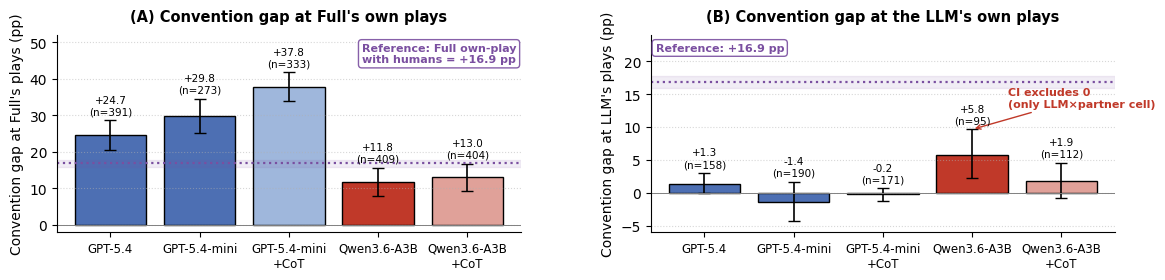

In [39]:
# Generate two-panel Figure A7
fig, (axA, axB) = _plt.subplots(1, 2, figsize=(11.5, 2.9), sharey=False,
                                gridspec_kw={'wspace': 0.28})
x = _np.arange(len(LLM_CONFIGS))
_COLORS = ['#4D6FB3', '#4D6FB3', '#9FB7DC', '#C03929', '#E0A199']

def _draw(ax, results, title, ylabel, ylim, ref_line=None,
          mark_idx=None, mark_label=None):
    gaps = [r[2] for r in results]
    yerr = _np.array([[r[2] - r[3], r[4] - r[2]] for r in results]).T
    ns = [r[1] for r in results]
    labels = [r[0] for r in results]
    ax.bar(x, gaps, yerr=yerr, capsize=4, color=_COLORS,
           edgecolor='black', linewidth=1.0,
           error_kw=dict(ecolor='black', lw=1.2))
    ax.axhline(0, color='gray', lw=0.7)
    if ref_line is not None:
        rline_y, _, rline_band = ref_line
        ax.axhline(rline_y, color='#7A4FA0', linestyle=':', lw=1.6)
        if rline_band is not None:
            ax.axhspan(rline_band[0], rline_band[1], color='#7A4FA0', alpha=0.10)
    if mark_idx is not None:
        i = mark_idx
        ax.annotate(mark_label,
                    xy=(x[i], gaps[i] + (yerr[1][i])),
                    xytext=(x[i] + 0.4, ylim[1] * 0.6),
                    ha='left', va='center', fontsize=8.0,
                    color='#C03929', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='#C03929', lw=1.0))
    for xi, gi, hi_v, n in zip(x, gaps, [r[4] for r in results], ns):
        ax.text(xi, hi_v + (ylim[1] - ylim[0]) * 0.02,
                f'{gi:+.1f}\n(n={n})', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8.5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(ylim)
    ax.set_xlim(-0.6, len(results) - 0.4)
    ax.set_title(title, fontsize=10.5, fontweight='bold', pad=10)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

_draw(axA, panel_a,
      title="(A) Convention gap at Full's own plays",
      ylabel="Convention gap at Full's plays (pp)",
      ylim=(-2, 52),
      ref_line=(16.9, 'Full own-play with humans (+16.9 pp)', (16.0, 17.8)))
axA.text(0.99, 0.96,
         'Reference: Full own-play\nwith humans = +16.9 pp',
         transform=axA.transAxes, ha='right', va='top', fontsize=8.0,
         color='#7A4FA0', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor='#7A4FA0', alpha=0.9))

_draw(axB, panel_b,
      title="(B) Convention gap at the LLM's own plays",
      ylabel="Convention gap at LLM's plays (pp)",
      ylim=(-6, 24),
      ref_line=(16.9, 'Full own-play with humans (+16.9 pp)', (16.0, 17.8)),
      mark_idx=3,
      mark_label='CI excludes 0\n(only LLM×partner cell)')
axB.text(0.01, 0.96,
         'Reference: +16.9 pp',
         transform=axB.transAxes, ha='left', va='top', fontsize=8.0,
         color='#7A4FA0', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor='#7A4FA0', alpha=0.9))

_plt.subplots_adjust(left=0.07, right=0.99, top=0.86, bottom=0.18)
_plt.savefig(_OUT_PATH, dpi=200, bbox_inches='tight')
print(f'Saved figure to {_OUT_PATH}')
_plt.show()


In [40]:
# Sanity check: values quoted in main paper edits and the appendix
print('Panel A range (gap):')
gaps_a = [r[2] for r in panel_a]
print(f'  min = {min(gaps_a):+5.2f}pp, max = {max(gaps_a):+5.2f}pp')
n_above_ref = sum(1 for g in gaps_a if g > 16.9)
print(f'  values above the +16.9 pp human reference: {n_above_ref} of {len(gaps_a)}')

print('\nPanel B Qwen3.6-A3B × Full (no CoT):')
qwen = [r for r in panel_b if r[0] == 'Qwen3.6-A3B'][0]
print(f'  n={qwen[1]}, gap={qwen[2]:+5.2f}pp, CI=[{qwen[3]:+5.2f}, {qwen[4]:+5.2f}]')

print('\nPanel B Qwen3.6-A3B × Full (with CoT):')
qwen_cot = [r for r in panel_b if r[0] == 'Qwen3.6-A3B\n+CoT'][0]
print(f'  n={qwen_cot[1]}, gap={qwen_cot[2]:+5.2f}pp, CI=[{qwen_cot[3]:+5.2f}, {qwen_cot[4]:+5.2f}]')


Panel A range (gap):
  min = +11.85pp, max = +37.80pp
  values above the +16.9 pp human reference: 3 of 5

Panel B Qwen3.6-A3B × Full (no CoT):
  n=95, gap=+5.75pp, CI=[+2.32, +9.65]

Panel B Qwen3.6-A3B × Full (with CoT):
  n=112, gap=+1.86pp, CI=[-0.81, +4.57]


---
## v8 Review-commitment analyses

Additions promised in the NeurIPS 2026 author-response period (see
`Manuscript/review_round_2026_0724/v8_revision_plan.md`):

1. **Joint-inference posterior variant** (`src/joint_posterior.py`, `src/joint_replay.py`):
   exact full-hand joint inference with without-replacement weights, marginalized to the
   played card. Verification targets: headline gaps +28.2→+26.2 / +16.9→+16.4 / −0.5→−0.7 pp;
   brute-force max discrepancy 0.
2. **Cluster-robust statistics** (`src/cluster_stats.py`): game- and player/participant-level
   bootstrap CIs; clustered z for the zero-hint and Full-vs-Outer tests.
3. **Within-participant partner analysis**: 228 participants; Full−Outer paired Δgap +19.7 pp
   (22/0 sign split at ≥3 games/cell); Full−Intentional not separable.
4. **Lives-remaining stratification** and **optimality-ceiling ratios**.


In [41]:
# v9 Appendix (app:joint): the paper's joint posterior vs the per-card approximation
# posterior_p_life_loss == JOINT after the v9 swap; v8 per-card values kept in posterior_marg_v8.
from sklearn.metrics import roc_auc_score
import json as _json
import pandas as _pd
from src.joint_replay import OUT_TIMING
from src.corpus import filter_truncated_games, _tier1_mask

settings65 = [('Human-Human', human_df), ('Human-AI (human plays)', hai_human), ('AI-AI', agent_df)]
print('=== Headline gaps: joint (paper) vs per-card approximation ===')
for name, df in settings65:
    jp = df['posterior_p_life_loss'].mean(); mp = df['posterior_marg_v8'].mean()
    lo = df['life_lost'].mean()
    print(f'{name}: joint gap {100*(jp-lo):+.1f} pp (post {jp:.1%}) | per-card {100*(mp-lo):+.1f} pp (post {mp:.1%}) | difference {(mp-jp)*100:+.2f} pp')
print()
print('=== Per-play differences ===')
for name, df in settings65:
    d = (df['posterior_p_life_loss'] - df['posterior_marg_v8']).to_numpy()
    nz = d[abs(d) > 1e-12]
    print(f'{name}: {len(nz)/len(d):.1%} of plays differ ({int((nz>0).sum())} joint-higher / {int((nz<0).sum())} joint-lower), mean|d| {abs(d).mean()*100:.3f} pp')
print()
print('=== Brier / AUC: joint vs per-card ===')
for name, df in settings65:
    y = df['life_lost'].to_numpy()
    bj = ((df['posterior_p_life_loss'] - y)**2).mean(); bm = ((df['posterior_marg_v8'] - y)**2).mean()
    aj = roc_auc_score(y, df['posterior_p_life_loss']); am = roc_auc_score(y, df['posterior_marg_v8'])
    print(f'{name}: Brier {bj:.4f} vs {bm:.4f} | AUC {aj:.4f} vs {am:.4f}')
print()
print('=== Hint-count decomposition: joint (per-card) ===')
for h in [0, 1, '2+']:
    row = []
    for name, df in settings65:
        sub = df[df['hints_on_card'] >= 2] if h == '2+' else df[df['hints_on_card'] == h]
        gj = sub['posterior_p_life_loss'].mean() - sub['life_lost'].mean()
        gm = sub['posterior_marg_v8'].mean() - sub['life_lost'].mean()
        row.append(f'{gj*100:+.1f} ({gm*100:+.1f})')
    print(f'{h} hints: HH {row[0]} | HAI {row[1]} | AA {row[2]} (pp)')
print()
print('=== Per-AI-partner human gaps: joint (per-card) ===')
for ai in ['full', 'intentional', 'outer']:
    sub = hai_human[hai_human['partner_type'] == ai]
    gj = sub['posterior_p_life_loss'].mean() - sub['life_lost'].mean()
    gm = sub['posterior_marg_v8'].mean() - sub['life_lost'].mean()
    print(f'{display_name(ai)}: {gj*100:+.1f} pp ({gm*100:+.1f})')

hh_v = _pd.read_csv('../data/processed/human_play_records.csv')
hh_v = filter_truncated_games(hh_v)
bad = set(hh_v.loc[_tier1_mask(hh_v['player']), 'game_key'].unique())
hh_v = hh_v[~hh_v['game_key'].isin(bad)].copy()
hh_v['life_lost'] = (~hh_v['was_playable']).astype(int)
hh_vj = _swap_to_joint(hh_v, 'hanab_live')
jp = hh_vj['posterior_p_life_loss'].mean(); mp = hh_vj['posterior_marg_v8'].mean(); lo = hh_vj['life_lost'].mean()
print(f'\nGame-level-only H-H variant ({hh_vj["game_key"].nunique()} games, {len(hh_vj):,} plays): joint {100*(jp-lo):+.1f} pp (per-card {100*(mp-lo):+.1f})')

t = _json.loads(open(OUT_TIMING).read())
print(f"\nVerification: {t['brute_checks']} brute-force spot-checks on the three corpora (max diff {t['brute_max_absdiff']:.1e}); +96 checks (max diff 0) on the LLM corpus")
print(f"Cost: {t['plays']:,} plays; per-card {t['marginal_time']/t['plays']*1e6:.0f} us/play, joint {t['joint_time']/t['plays']*1e6:.0f} us/play, wall {t['wall_clock_s']:.0f} s (single core)")

=== Headline gaps: joint (paper) vs per-card approximation ===
Human-Human: joint gap +26.2 pp (post 31.4%) | per-card +28.2 pp (post 33.5%) | difference +2.03 pp
Human-AI (human plays): joint gap +16.4 pp (post 39.1%) | per-card +16.9 pp (post 39.6%) | difference +0.50 pp


AI-AI: joint gap -0.7 pp (post 8.7%) | per-card -0.5 pp (post 8.9%) | difference +0.19 pp

=== Per-play differences ===
Human-Human: 17.3% of plays differ (196 joint-higher / 1367 joint-lower), mean|d| 2.128 pp
Human-AI (human plays): 11.0% of plays differ (538 joint-higher / 1170 joint-lower), mean|d| 0.747 pp
AI-AI: 4.4% of plays differ (0 joint-higher / 2787 joint-lower), mean|d| 0.194 pp

=== Brier / AUC: joint vs per-card ===
Human-Human: Brier 0.1753 vs 0.1905 | AUC 0.8146 vs 0.8107
Human-AI (human plays): Brier 0.1588 vs 0.1623 | AUC 0.8705 vs 0.8682
AI-AI: Brier 0.0336 vs 0.0337 | AUC 0.9802 vs 0.9799

=== Hint-count decomposition: joint (per-card) ===
0 hints: HH +46.2 (+47.8) | HAI -12.2 (-12.0) | AA -12.8 (-11.4) (pp)
1 hints: HH +35.6 (+38.5) | HAI +24.7 (+25.4) | AA +0.9 (+1.2) (pp)
2+ hints: HH +1.6 (+1.7) | HAI +0.9 (+1.0) | AA -0.1 (-0.1) (pp)

=== Per-AI-partner human gaps: joint (per-card) ===
Full: +24.1 pp (+24.6)
Intentional: +20.2 pp (+20.8)
Outer: +6.2 pp (+6.7)


In [9]:
# v8-A2: Cluster-robust statistics (game- and player/participant-level)
from src.cluster_stats import (cluster_bootstrap_gap_ci, cluster_robust_se_mean,
                               clustered_diff_z, paired_stats)
from math import erfc

pmap = pd.read_csv('../data/processed/hai_game_participant_map.csv')
hai_p = hai_human.merge(pmap, on='game_id', how='left')
assert hai_p['participant_id'].notna().all()

def fmt_ci(ci):
    return f'[{ci[0]*100:+.1f}, {ci[1]*100:+.1f}]'

print('=== Headline gap CIs: play-level / game-cluster / person-cluster ===')
for name, df, person in [('Human-Human', human_df, 'player'),
                         ('Human-AI (human plays)', hai_p, 'participant_id'),
                         ('AI-AI', agent_df, None)]:
    gap = df['posterior_p_life_loss'].mean() - df['life_lost'].mean()
    line = (f'{name}: gap {gap*100:+.1f} pp | play {fmt_ci(cluster_bootstrap_gap_ci(df, None))} | '
            f'game {fmt_ci(cluster_bootstrap_gap_ci(df, "game_key"))} '
            f'({df["game_key"].nunique():,} games)')
    if person:
        line += (f' | person {fmt_ci(cluster_bootstrap_gap_ci(df, person))} '
                 f'({df[person].nunique()} clusters)')
    print(line)

print()
print('=== Per-AI-partner gap CIs (Table A3): play / game / participant ===')
for ai in ['full', 'intentional', 'outer']:
    sub = hai_p[hai_p['partner_type'] == ai]
    gap = sub['posterior_p_life_loss'].mean() - sub['life_lost'].mean()
    print(f'{display_name(ai)}: {gap*100:+.1f} pp | play {fmt_ci(cluster_bootstrap_gap_ci(sub, None))} | '
          f'game {fmt_ci(cluster_bootstrap_gap_ci(sub, "game_key"))} | '
          f'participant {fmt_ci(cluster_bootstrap_gap_ci(sub, "participant_id"))} '
          f'({sub["game_key"].nunique()} g / {sub["participant_id"].nunique()} p)')

print()
print('=== Zero-hint success z (H-H vs H-AI): unpooled / pooled / clustered ===')
hh0 = human_df[human_df['hints_on_card'] == 0]
ha0 = hai_p[hai_p['hints_on_card'] == 0]
p1, p2 = hh0['was_playable'].mean(), ha0['was_playable'].mean()
n1, n2 = len(hh0), len(ha0)
se_unpooled = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
p_pool = (hh0['was_playable'].sum() + ha0['was_playable'].sum()) / (n1 + n2)
se_pooled = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
z_u, z_pl = (p1-p2)/se_unpooled, (p1-p2)/se_pooled
se1g = cluster_robust_se_mean(hh0['was_playable'].to_numpy(float), hh0['game_key'].to_numpy())
se2g = cluster_robust_se_mean(ha0['was_playable'].to_numpy(float), ha0['game_key'].to_numpy())
z_g = (p1-p2)/np.sqrt(se1g**2 + se2g**2)
se1i = cluster_robust_se_mean(hh0['was_playable'].to_numpy(float), hh0['player'].to_numpy())
se2i = cluster_robust_se_mean(ha0['was_playable'].to_numpy(float), ha0['participant_id'].to_numpy())
z_i = (p1-p2)/np.sqrt(se1i**2 + se2i**2)
print(f'rates: H-H {p1:.1%} (n={n1:,}) vs H-AI {p2:.1%} (n={n2:,})')
for lbl, z in [('unpooled (paper convention)', z_u), ('pooled', z_pl),
               ('game-clustered (CR0)', z_g), ('player/participant-clustered', z_i)]:
    print(f'  z ({lbl}) = {z:.2f}, p = {erfc(abs(z)/np.sqrt(2)):.2e}')

print()
print('=== Full vs Outer Partner Loss: play-level Welch + clustered z ===')
fu = hai_p[hai_p['partner_type'] == 'full']
ou = hai_p[hai_p['partner_type'] == 'outer']
welch = stats.ttest_ind(fu['life_lost'], ou['life_lost'], equal_var=False)
t_w, p_w, df_w = welch.statistic, welch.pvalue, welch.df
z_gm, p_gm = clustered_diff_z(fu, ou, 'life_lost', 'game_key')
z_pt, p_pt = clustered_diff_z(fu, ou, 'life_lost', 'participant_id')
print(f'Partner Loss: Full {fu["life_lost"].mean():.1%} vs Outer {ou["life_lost"].mean():.1%}')
print(f'  play-level Welch t = {t_w:.2f} (Welch df = {df_w:,.1f}, p = {p_w:.2e})')
print(f'  game-clustered z = {z_gm:.2f} (p = {p_gm:.2e})')
print(f'  participant-clustered z = {z_pt:.2f} (p = {p_pt:.2e})')


=== Headline gap CIs: play-level / game-cluster / person-cluster ===


Human-Human: gap +26.2 pp | play [+25.5, +26.8] | game [+25.3, +27.0] (425 games) | person [+24.5, +27.8] (155 clusters)


Human-AI (human plays): gap +16.4 pp | play [+15.8, +16.9] | game [+15.7, +17.1] (2,035 games) | person [+15.0, +17.8] (228 clusters)


AI-AI: gap -0.7 pp | play [-0.9, -0.6] | game [-0.9, -0.6] (4,900 games)

=== Per-AI-partner gap CIs (Table A3): play / game / participant ===


Full: +24.1 pp | play [+23.2, +25.1] | game [+23.1, +25.2] | participant [+22.9, +24.9] (682 g / 129 p)


Intentional: +20.2 pp | play [+19.3, +21.2] | game [+19.2, +21.3] | participant [+18.0, +22.4] (646 g / 131 p)


Outer: +6.2 pp | play [+5.2, +7.2] | game [+5.2, +7.2] | participant [+4.8, +7.5] (707 g / 122 p)

=== Zero-hint success z (H-H vs H-AI): unpooled / pooled / clustered ===
rates: H-H 77.7% (n=484) vs H-AI 15.7% (n=778)
  z (unpooled (paper convention)) = 26.98, p = 2.45e-160
  z (pooled) = 21.91, p = 1.94e-106
  z (game-clustered (CR0)) = 21.69, p = 2.66e-104
  z (player/participant-clustered) = 15.79, p = 3.91e-56

=== Full vs Outer Partner Loss: play-level Welch + clustered z ===
Partner Loss: Full 14.4% vs Outer 34.4%
  play-level Welch t = -24.61 (Welch df = 10,141.8, p = 6.12e-130)
  game-clustered z = -23.82 (p = 2.03e-125)
  participant-clustered z = -6.28 (p = 3.35e-10)


In [43]:
# v8-A3: Participant x partner structure and within-participant paired contrasts
pt_sets = hai_p.groupby('participant_id')['partner_type'].agg(lambda s: frozenset(s))
print(f'Observed participants: {len(pt_sets)} (published dataset description: 240 players; '
      f'the 12 additional IDs have no logged completed game in the shipped metadata)')
for k, v in pt_sets.map(len).value_counts().sort_index().items():
    print(f'  played exactly {k} AI type(s): {v} ({v/len(pt_sets):.1%})')
gcount = hai_p.groupby(['participant_id', 'partner_type'])['game_key'].nunique()
tot = hai_p.groupby('participant_id')['game_key'].nunique()
print(f'games per participant x partner cell: median {gcount.median():.0f}, '
      f'mean {gcount.mean():.1f}, max {gcount.max()}')
print(f'total games per participant: median {tot.median():.0f}, mean {tot.mean():.1f}, '
      f'max {tot.max()} (self-paced, heavy-tailed)')

per = hai_p.groupby(['participant_id', 'partner_type']).agg(
    n_games=('game_key', 'nunique'),
    post=('posterior_p_life_loss', 'mean'),
    loss=('life_lost', 'mean'))
per['gap'] = per['post'] - per['loss']

for min_g in [1, 3]:
    print(f'--- paired contrasts, threshold >= {min_g} game(s) per cell ---')
    for a, b in [('full', 'outer'), ('intentional', 'outer'), ('full', 'intentional')]:
        ga = per.xs(a, level='partner_type'); gb = per.xs(b, level='partner_type')
        ga, gb = ga[ga['n_games'] >= min_g], gb[gb['n_games'] >= min_g]
        common = ga.index.intersection(gb.index)
        r = paired_stats((ga.loc[common, 'gap'] - gb.loc[common, 'gap']).to_numpy())
        rl = paired_stats((ga.loc[common, 'loss'] - gb.loc[common, 'loss']).to_numpy())
        print(f'{display_name(a)} - {display_name(b)}: n={r["n"]}, '
              f'dGap {r["mean"]*100:+.1f} pp CI [{r["ci"][0]*100:+.1f}, {r["ci"][1]*100:+.1f}], '
              f'sign {r["n_pos"]}/{r["n_neg"]}, sign-p {r["sign_p"]:.2g}, '
              f'Wilcoxon p {r["wilcoxon_p"]:.2g}; dLoss {rl["mean"]*100:+.1f} pp '
              f'CI [{rl["ci"][0]*100:+.1f}, {rl["ci"][1]*100:+.1f}]')

trip = per.reset_index().pivot_table(index='participant_id', columns='partner_type',
                                     values='gap').dropna()
print(f'Participants who played all three AIs (n={len(trip)}): '
      f'gap(Full)>gap(Outer) for {(trip["full"]>trip["outer"]).mean():.1%}; '
      f'both Full and Intentional exceed Outer for '
      f'{((trip["full"]>trip["outer"])&(trip["intentional"]>trip["outer"])).mean():.1%}')


Observed participants: 228 (published dataset description: 240 players; the 12 additional IDs have no logged completed game in the shipped metadata)
  played exactly 1 AI type(s): 122 (53.5%)
  played exactly 2 AI type(s): 58 (25.4%)
  played exactly 3 AI type(s): 48 (21.1%)
games per participant x partner cell: median 1, mean 5.3, max 207
total games per participant: median 2, mean 8.9, max 566 (self-paced, heavy-tailed)
--- paired contrasts, threshold >= 1 game(s) per cell ---
Full - Outer: n=69, dGap +16.0 pp CI [+12.2, +19.8], sign 57/12, sign-p 3.7e-08, Wilcoxon p 8.4e-10; dLoss -22.3 pp CI [-26.4, -18.3]
Intentional - Outer: n=64, dGap +18.8 pp CI [+14.7, +22.9], sign 58/6, sign-p 9e-12, Wilcoxon p 3.4e-10; dLoss -21.3 pp CI [-24.7, -17.8]
Full - Intentional: n=69, dGap -3.4 pp CI [-7.8, +0.9], sign 32/37, sign-p 0.63, Wilcoxon p 0.34; dLoss +0.7 pp CI [-2.4, +3.7]
--- paired contrasts, threshold >= 3 game(s) per cell ---
Full - Outer: n=22, dGap +19.7 pp CI [+16.4, +23.1], sign 

In [44]:
# v8-A5: Convention gap and loss rate by life tokens remaining
print('=== Gap by lives remaining (3/2/1) per setting ===')
for name, df in [('Human-Human', human_df), ('Human-AI (human plays)', hai_human),
                 ('AI-AI', agent_df)]:
    for lives in (3, 2, 1):
        sub = df[df['life_tokens'] == lives]
        gap = sub['posterior_p_life_loss'].mean() - sub['life_lost'].mean()
        print(f'{name} lives={lives}: n={len(sub):,}, post {sub["posterior_p_life_loss"].mean():.1%}, '
              f'loss {sub["life_lost"].mean():.1%}, gap {gap*100:+.1f} pp')
    sub = df[df['life_tokens'] > 1]
    g_all = df['posterior_p_life_loss'].mean() - df['life_lost'].mean()
    g_ex = sub['posterior_p_life_loss'].mean() - sub['life_lost'].mean()
    print(f'{name}: gap excluding last-life plays {g_ex*100:+.1f} pp '
          f'(all plays {g_all*100:+.1f}; excluded {len(df)-len(sub):,} = '
          f'{(len(df)-len(sub))/len(df):.1%})')


=== Gap by lives remaining (3/2/1) per setting ===
Human-Human lives=3: n=6,439, post 31.7%, loss 4.0%, gap +27.7 pp
Human-Human lives=2: n=2,004, post 29.8%, loss 6.5%, gap +23.3 pp
Human-Human lives=1: n=574, post 34.2%, loss 15.0%, gap +19.2 pp
Human-Human: gap excluding last-life plays +26.6 pp (all plays +26.2; excluded 574 = 6.4%)
Human-AI (human plays) lives=3: n=8,577, post 34.4%, loss 16.4%, gap +17.9 pp
Human-AI (human plays) lives=2: n=4,118, post 44.2%, loss 28.0%, gap +16.2 pp
Human-AI (human plays) lives=1: n=2,777, post 45.9%, loss 34.1%, gap +11.8 pp
Human-AI (human plays): gap excluding last-life plays +17.4 pp (all plays +16.4; excluded 2,777 = 17.9%)
AI-AI lives=3: n=47,984, post 5.3%, loss 5.5%, gap -0.2 pp
AI-AI lives=2: n=9,806, post 18.3%, loss 20.3%, gap -2.0 pp
AI-AI lives=1: n=5,100, post 22.1%, loss 25.3%, gap -3.2 pp
AI-AI: gap excluding last-life plays -0.5 pp (all plays -0.7; excluded 5,100 = 8.1%)


In [45]:
# v8-A4: Optimality-ceiling ratios (gap / mean posterior)
def ceiling_row(label, df):
    mp = df['posterior_p_life_loss'].mean()
    gap = mp - df['life_lost'].mean()
    print(f'{label}: post {mp:.1%}, gap {gap*100:+.1f} pp, gap/ceiling {gap/mp:.1%}')

ceiling_row('Human-Human (all)', human_df)
for pt in ['expert-expert', 'expert-intermediate', 'intermediate-intermediate',
           'expert-beginner', 'intermediate-beginner', 'beginner-beginner']:
    sub = human_df[human_df['pair_type'] == pt]
    if len(sub):
        ceiling_row(f'H-H {pt}', sub)
ceiling_row('Human-AI (human plays, all)', hai_human)
for ai in ['full', 'intentional', 'outer']:
    ceiling_row(f'H-AI vs {display_name(ai)}', hai_human[hai_human['partner_type'] == ai])
ceiling_row('AI-AI (all)', agent_df)


Human-Human (all): post 31.4%, gap +26.2 pp, gap/ceiling 83.2%
H-H expert-expert: post 31.6%, gap +29.1 pp, gap/ceiling 92.1%
H-H expert-intermediate: post 28.8%, gap +25.2 pp, gap/ceiling 87.5%
H-H intermediate-intermediate: post 30.2%, gap +25.4 pp, gap/ceiling 84.0%
H-H expert-beginner: post 42.4%, gap +38.0 pp, gap/ceiling 89.7%
H-H intermediate-beginner: post 36.1%, gap +27.2 pp, gap/ceiling 75.2%
H-H beginner-beginner: post 33.1%, gap +21.1 pp, gap/ceiling 63.7%
Human-AI (human plays, all): post 39.1%, gap +16.4 pp, gap/ceiling 41.9%
H-AI vs Full: post 38.5%, gap +24.1 pp, gap/ceiling 62.7%
H-AI vs Intentional: post 37.9%, gap +20.2 pp, gap/ceiling 53.5%
H-AI vs Outer: post 40.6%, gap +6.2 pp, gap/ceiling 15.3%
AI-AI (all): post 8.7%, gap -0.7 pp, gap/ceiling -8.5%


In [46]:
# v8-C13: LaTeX-ready values for the new main-text tables (Section 4.1 / 4.3)
print('=== Section 4.1 headline table (per setting) ===')
for name, df, person in [('Human-Human', human_df, 'player'),
                         ('Human-AI', hai_p, 'participant_id'),
                         ('AI-AI', agent_df, None)]:
    mp = df['posterior_p_life_loss'].mean(); lo = df['life_lost'].mean()
    ci_p = cluster_bootstrap_gap_ci(df, None)
    ci_g = cluster_bootstrap_gap_ci(df, 'game_key')
    row = (f'{name} & {len(df):,} & {mp*100:.1f} & {lo*100:.1f} & {(mp-lo)*100:+.1f} & '
           f'[{ci_p[0]*100:+.1f}, {ci_p[1]*100:+.1f}] & '
           f'[{ci_g[0]*100:+.1f}, {ci_g[1]*100:+.1f}]')
    if person:
        ci_i = cluster_bootstrap_gap_ci(df, person)
        row += f' & [{ci_i[0]*100:+.1f}, {ci_i[1]*100:+.1f}]'
    else:
        row += ' & ---'
    print(row + r' \\')

print()
print('=== Section 4.3 per-partner table (human plays) ===')
for ai in ['full', 'intentional', 'outer']:
    sub = hai_p[hai_p['partner_type'] == ai]
    mp = sub['posterior_p_life_loss'].mean(); lo = sub['life_lost'].mean()
    print(f'{display_name(ai)} & {len(sub):,} & {mp*100:.1f} & {lo*100:.1f} & '
          f'{(mp-lo)*100:+.1f}' + r' \\')


=== Section 4.1 headline table (per setting) ===


Human-Human & 9,017 & 31.4 & 5.3 & +26.2 & [+25.5, +26.8] & [+25.3, +27.0] & [+24.5, +27.8] \\


Human-AI & 15,472 & 39.1 & 22.7 & +16.4 & [+15.8, +16.9] & [+15.7, +17.1] & [+15.0, +17.8] \\


AI-AI & 62,890 & 8.7 & 9.4 & -0.7 & [-0.9, -0.6] & [-0.9, -0.6] & --- \\

=== Section 4.3 per-partner table (human plays) ===
Full & 4,769 & 38.5 & 14.4 & +24.1 \\
Intentional & 5,122 & 37.9 & 17.6 & +20.2 \\
Outer & 5,581 & 40.6 & 34.4 & +6.2 \\
